# 1. Import, Config, and UI

In [1]:
import sys, json, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import talib as ta
import umap as umap_lib

from talib import abstract
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SKStandardScaler
from sklearn.manifold import TSNE
from dataclasses import dataclass, field

from config import FeatureConfig, Indicator
from utils import  inverse_x, inverse_cond, inverse_price, save_split, save_scalers, save_variant, load_split, load_scalers, load_variant, make_dataloader, make_all_dataloaders

## UI

In [2]:
cfg = FeatureConfig(
    name        = "v1_trial04",
    description = "baseline 16 assets, window=20, seq_depth=20",

    symbols = [
        "AAPL", "AMZN", "CAT", "EEM", "GOOGL", "JNJ",
        "JPM",  "KO",   "META","MSFT","NVDA",  "SPY",
        "TLT",  "TSLA", "GLD", "XOM",
    ],

    train_period = ("2010-01-01", "2017-12-31"),
    val_period   = ("2018-01-01", "2021-12-31"),
    test_period  = ("2022-01-01", "2025-12-31"),

    window_size    = 5,
    sequence_depth = 20,
    use_sequence  = True,   # False = x shape [B,A,W,F], True = [B,A,W,D*F]
    use_cyclical = True,
    cyclical_features = "weekday",
    indicators = [
        Indicator("RSI",    {"timeperiod": 14},                                    norm_type="minmax"),
        Indicator("MACD",   {"fastperiod": 12, "slowperiod": 26, "signalperiod": 9}, norm_type=None),
        Indicator("BBANDS", {"timeperiod": 20, "nbdevup": 2.0, "nbdevdn": 2.0},    norm_type="distance_close"),
        Indicator("ATR",    {"timeperiod": 14},                                    norm_type="minmax"),
        Indicator("ROC",    {"timeperiod": 10},                                    norm_type="minmax"),
    ],
    batch_sizes = {"train": 64, "val": 64, "test": 1},
    random_seed = 72,

    x_scaler = "robust",  # Options: 'standard', 'minmax', 'robust'
    x_scaler_axis = "per_channel_global",  # Options: 'per_channel_global', 'per_channel_per_symbol', 'global'
    cond_scaler = "standard",  # Options: 'standard', 'minmax', 'robust'
    cond_scaler_axis = "per_feature_global",  # Options: 'per_feature_global', 'per_feature_per_symbol
)

cfg.name = f"{cfg.name}_w{cfg.window_size}_d{cfg.sequence_depth}_asset{len(cfg.symbols)}"
cfg.description = f"baseline with {len(cfg.symbols)} assets | window={cfg.window_size} seq_depth={cfg.sequence_depth}"
cfg.description += f" | indicators={[ind.name for ind in cfg.indicators]}"
cfg.description += f" | x_scaler={cfg.x_scaler}({cfg.x_scaler_axis})"
cfg.description += f" | cond_scaler={cfg.cond_scaler}({cfg.cond_scaler_axis})"
cfg.description += f" | use_sequence={cfg.use_sequence}"

variant      = f"{cfg.x_scaler}_{cfg.cond_scaler}"
processed_dir_name = f"{cfg.name}_{variant}"
save_dir = cfg.save_dir / cfg.name

processed_dir = cfg.save_dir / processed_dir_name
processed_dir.mkdir(parents=True, exist_ok=True)

# plots_dir = cfg.save_dir / processed_dir_name / "plots"
# plots_dir.mkdir(parents=True, exist_ok=True)

analysis_dir = cfg.save_dir / processed_dir_name / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

print(f"Config      : {cfg.name}")
print(f"Description : {cfg.description}")
print(f"Symbols     : {len(cfg.symbols)} assets")
print(f"Train       : {cfg.train_period[0]} → {cfg.train_period[1]}")
print(f"Val         : {cfg.val_period[0]}   → {cfg.val_period[1]}")
print(f"Test        : {cfg.test_period[0]}  → {cfg.test_period[1]}")
print(f"Window      : {cfg.window_size}  |  seq_depth={cfg.sequence_depth}  use_sequence={cfg.use_sequence}")
print(f"Window Strides: {cfg.window_strides}")
print(f"Ind. shift  : {cfg.indicator_shift}  (auto = window_size)")
print(f"Indicators  : {[ind.name for ind in cfg.indicators]}")
print(f"Save dir    : {save_dir}")

Config      : v1_trial04_w5_d20_asset16
Description : baseline with 16 assets | window=5 seq_depth=20 | indicators=['RSI', 'MACD', 'BBANDS', 'ATR', 'ROC'] | x_scaler=robust(per_channel_global) | cond_scaler=standard(per_feature_global) | use_sequence=True
Symbols     : 16 assets
Train       : 2010-01-01 → 2017-12-31
Val         : 2018-01-01   → 2021-12-31
Test        : 2022-01-01  → 2025-12-31
Window      : 5  |  seq_depth=20  use_sequence=True
Window Strides: {'train': 1, 'val': 1, 'test': 5}
Ind. shift  : 5  (auto = window_size)
Indicators  : ['RSI', 'MACD', 'BBANDS', 'ATR', 'ROC']
Save dir    : /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16


# 2. Download & Clean Raw Data

In [3]:
def plot_missing_data(df: pd.DataFrame, assets: list, column: str, title: str = ""):
    prices = df[column]
    fig, axes = plt.subplots(len(assets), 1, figsize=(14, max(8, len(assets) * 1.2)))
    if title:
        fig.suptitle(title, fontsize=10, y=1.001)

    for ax, sym in zip(axes, assets):
        series = prices[sym]
        ax.plot(series.index, series.values, lw=0.8)
        nan_idx = series.index[series.isna()]
        if len(nan_idx):
            ax.scatter(nan_idx, [series.mean()] * len(nan_idx),
                       color="red", marker="x", s=40, zorder=5, label="NaN")
        ax.set_title(sym, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    nan_counts = df[column].isna().sum()
    if nan_counts.any():
        print("NaN counts per asset:")
        print(nan_counts[nan_counts > 0].to_string())
    else:
        print("✓ No NaN values found.")


def process_missing_data(df: pd.DataFrame) -> pd.DataFrame:
    first_valid = df.notna().all(axis=1).idxmax()
    df = df.loc[first_valid:]
    df.ffill(inplace=True)
    return df


def summarize_split(name: str, df: pd.DataFrame):
    n_days   = len(df)
    n_assets = df.columns.get_level_values(1).nunique()
    d_start  = df.index[0].date()
    d_end    = df.index[-1].date()
    print(f"  {name:<6} │ {d_start} → {d_end} │ {n_days:>4} trading days │ {n_assets} assets")

In [4]:
splits = {
    "train": yf.download(cfg.symbols, start=cfg.train_period[0], end=cfg.train_period[1], interval=cfg.interval),
    "val"  : yf.download(cfg.symbols, start=cfg.val_period[0],   end=cfg.val_period[1],   interval=cfg.interval),
    "test" : yf.download(cfg.symbols, start=cfg.test_period[0],  end=cfg.test_period[1],  interval=cfg.interval),
}

# assets = splits["train"].columns.get_level_values(1).unique().tolist()
assets = cfg.symbols

for split_name, df_split in splits.items():
    splits[split_name] = process_missing_data(df_split)

df_train = splits["train"]
df_val   = splits["val"]
df_test  = splits["test"]

print("── Data Summary ──────────────────────────────────────────────────────")
for name, df_s in splits.items():
    summarize_split(name, df_s)
print(f"  {'TOTAL':<6} │ {'':>27} │ {sum(len(d) for d in splits.values()):>4} trading days")

[*********************100%***********************]  16 of 16 completed
[*********************100%***********************]  16 of 16 completed
[*********************100%***********************]  16 of 16 completed

── Data Summary ──────────────────────────────────────────────────────
  train  │ 2012-05-18 → 2017-12-29 │ 1414 trading days │ 16 assets
  val    │ 2018-01-02 → 2021-12-30 │ 1007 trading days │ 16 assets
  test   │ 2022-01-03 → 2025-12-30 │ 1002 trading days │ 16 assets
  TOTAL  │                             │ 3423 trading days



/tmp/ipykernel_60103/720736769.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.ffill(inplace=True)


In [5]:
# cfg.indicator_shift = len(splits["test"])
# print(f"Ind. shift  : {cfg.indicator_shift}  (auto = window_size)")

# 3. Feature Engineering

## 3.1 Low-level helper

In [6]:
def apply_normalization(series: pd.Series, norm_type: str,
                        period: int, close: pd.Series = None) -> pd.Series:
    if norm_type is None:
        return series
    if norm_type == "zscore":
        return (series - series.rolling(period).mean()) / series.rolling(period).std()
    elif norm_type == "minmax":
        lo = series.rolling(period).min()
        hi = series.rolling(period).max()
        return (series - lo) / (hi - lo + 1e-8)
    elif norm_type == "pct_change":
        return series.pct_change()
    elif norm_type == "distance_close":
        if close is None:
            raise ValueError("distance_close requires close prices")
        return (close - series) / (close + 1e-8)
    else:
        print(f"Warning: unknown norm_type '{norm_type}', returning original.")
        return series

## 3.2 Add_* functions

In [7]:
def add_indicators(df: pd.DataFrame, assets: list, cfg) -> pd.DataFrame:
    parts = []
    for sym in assets:
        ohlcv = df.loc[:, df.columns.get_level_values(1) == sym].copy()
        ohlcv.columns = ohlcv.columns.get_level_values(0)
        close = ohlcv["Close"]
        ohlcv_dict = {k.lower(): ohlcv[k].values for k in ["Open","High","Low","Close","Volume"]}

        rows = {}
        for ind in cfg.indicators:
            try:
                func      = abstract.Function(ind.name)
                result    = func(ohlcv_dict, **ind.params)
                out_names = func.info["output_names"]
                period    = ind.params.get("timeperiod", 14)

                outputs = result    if isinstance(result, (tuple, list)) else [result]
                names   = out_names if isinstance(result, (tuple, list)) else \
                          ["_".join(str(v) for v in ind.params.values())]

                for arr, out in zip(outputs, names):
                    val  = pd.Series(arr, index=ohlcv.index)
                    val  = apply_normalization(val, ind.norm_type, period, close)
                    col  = f"{ind.name}_{out}"
                    if ind.norm_type:
                        col += f"_{ind.norm_type}"
                    rows[col] = val.shift(cfg.indicator_shift)

            except Exception as e:
                print(f"  ✗ {ind.name}/{sym}: {e}")

        parts.append(pd.DataFrame(rows, index=ohlcv.index))

    df_ind = pd.concat(parts, axis=1, keys=assets)
    df_ind = df_ind.swaplevel(axis=1).sort_index(axis=1)
    return pd.concat([df, df_ind], axis=1)


def add_cyclical(df: pd.DataFrame, assets: list,
                 cycle: str = "weekday") -> pd.DataFrame:
    """
    Append sin/cos cyclical time features for every asset.
    Columns added: (asset, weekday_sin), (asset, weekday_cos)
    """
    index = pd.to_datetime(df.index)
    if cycle == "weekday":
        values, period, name = index.dayofweek % 5, 5, "weekday"
    else:
        raise ValueError(f"Unsupported cycle: {cycle}")

    base = pd.DataFrame(
        {f"{name}_sin": np.sin(2 * np.pi * values / period),
         f"{name}_cos": np.cos(2 * np.pi * values / period)},
        index=df.index,
    )
    df_cyc = pd.concat([base.copy() for _ in assets], axis=1,
                       keys=assets).swaplevel(axis=1).sort_index(axis=1)
    return pd.concat([df, df_cyc], axis=1)


def add_log_return(df: pd.DataFrame, assets: list) -> pd.DataFrame:
    """
    Append log return of Close price per asset.
    Columns added: (asset, log_return)
    """
    close   = df.xs("Close", level=0, axis=1)
    log_ret = np.log(close / close.shift(1))
    log_ret.columns = pd.MultiIndex.from_tuples(
        [("log_return", sym) for sym in log_ret.columns]
    )
    log_ret = log_ret.swaplevel(axis=1).sort_index(axis=1)
    return pd.concat([df, log_ret], axis=1)


def drop_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """Remove raw OHLCV columns, keep only engineered features."""
    ohlcv_cols = [c for c in df.columns.get_level_values(0)
                  if c in {"Open", "High", "Low", "Close", "Volume"}]
    return df.drop(columns=list(set(ohlcv_cols)), level=0)

In [8]:
def add_cross_asset_vol(df, assets, window):
    """Cross-asset rolling volatility as conditioning signal."""
    close = df.xs("Close", level=0, axis=1)
    log_ret = np.log(close / close.shift(1))
    avg_vol = log_ret.rolling(window).std().mean(axis=1) * np.sqrt(252)
    rows    = pd.DataFrame(
        {sym: avg_vol for sym in assets},
        index=df.index,
    )
    rows.columns = pd.MultiIndex.from_tuples(
        [("cross_vol", sym) for sym in assets]
    )
    rows = rows.swaplevel(axis=1).sort_index(axis=1)
    return pd.concat([df, rows], axis=1)

## 3.3 Pipeline + Run

In [9]:
def build_feature_df(df_raw: pd.DataFrame, assets: list, cfg) -> pd.DataFrame:
    """
    Compose feature pipeline using add_* functions.
    Easy to extend: just add another add_*() line.
    """
    df = df_raw.copy()
    df = add_indicators(df, assets, cfg)
    if cfg.use_cyclical:
        df = add_cyclical(df, assets, cycle=cfg.cyclical_features)
    df = add_log_return(df, assets)
    # df = add_cross_asset_vol(df, assets, cfg.window_size)
    df = drop_ohlcv(df)
    return df


feat_splits = {}
for name, df_s in splits.items():
    feat        = build_feature_df(df_s, assets, cfg)
    feat_clean  = feat.dropna()
    feat_splits[name] = feat_clean
    n_feat = feat_clean.shape[1] // len(assets)
    print(f"  {name:<6} │ {len(feat):>4} → {len(feat_clean):>4} rows "
          f"(dropped {len(feat)-len(feat_clean)} warmup)  │  {n_feat} features/asset")

df_feat_train = feat_splits["train"]
df_feat_val   = feat_splits["val"]
df_feat_test  = feat_splits["test"]

# Sanity check — feature columns ของ 1 asset
feat_cols = df_feat_train.xs("AAPL", axis=1, level=0).columns.tolist()
print(f"\nFeatures ({len(feat_cols)}): {feat_cols}")

  train  │ 1414 → 1376 rows (dropped 38 warmup)  │  12 features/asset
  val    │ 1007 →  969 rows (dropped 38 warmup)  │  12 features/asset
  test   │ 1002 →  964 rows (dropped 38 warmup)  │  12 features/asset

Features (1): ['log_return']


# 4. Data Analysis

## 4.0 Setup output folders

In [10]:
tables_dir       = analysis_dir / "tables"
analysis_plots_dir = analysis_dir / "plots"
tables_dir.mkdir(parents=True, exist_ok=True)
analysis_plots_dir.mkdir(parents=True, exist_ok=True)

# ── naming helper ─────────────────────────────────────────────────────────
# ชื่อไฟล์ทุกอันจะ prefix ด้วย cfg.name  เช่น  "v3_trial01_4.1_return_dist.png"
def aplot(fname: str) -> Path:
    return analysis_plots_dir / f"{cfg.name}_{fname}"

def atable(fname: str) -> Path:
    return tables_dir / f"{cfg.name}_{fname}"

print(f"Config      : {cfg.name}")
print(f"Analysis → {analysis_dir}")
print(f"  plots/  : {analysis_plots_dir}")
print(f"  tables/ : {tables_dir}")

Config      : v1_trial04_w5_d20_asset16
Analysis → /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/analysis
  plots/  : /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/analysis/plots
  tables/ : /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/analysis/tables


## 4.1  Log-Return Distribution per Asset

✓ v1_trial04_w5_d20_asset16_return_stats.csv
            Mean       Std      Skew       Kurt       Min       Max    Sharpe   Ann.Ret   Ann.Vol
Ticker                                                                                           
TSLA    0.001716  0.029667  0.372814   5.710377 -0.156737  0.218292  0.918155  0.432404  0.470949
META    0.001082  0.022962  1.230892  17.472962 -0.124369  0.259371  0.748333  0.272772  0.364507
NVDA    0.002017  0.021431  1.879266  20.715413 -0.097308  0.260876  1.493733  0.508176  0.340205
AMZN    0.001202  0.018026  0.405865  10.354808 -0.116503  0.132178  1.058887  0.303012  0.286161
AAPL    0.000646  0.015448 -0.540887   6.595459 -0.131885  0.078794  0.663900  0.162811  0.245235
CAT     0.000528  0.014381 -0.010141   3.261053 -0.074546  0.075671  0.583218  0.133144  0.228293
MSFT    0.000863  0.014000 -0.179372  10.530471 -0.121033  0.099413  0.979086  0.217588  0.222235
GOOGL   0.000888  0.013634  1.382052  17.705252 -0.083455  0.150645  1.03

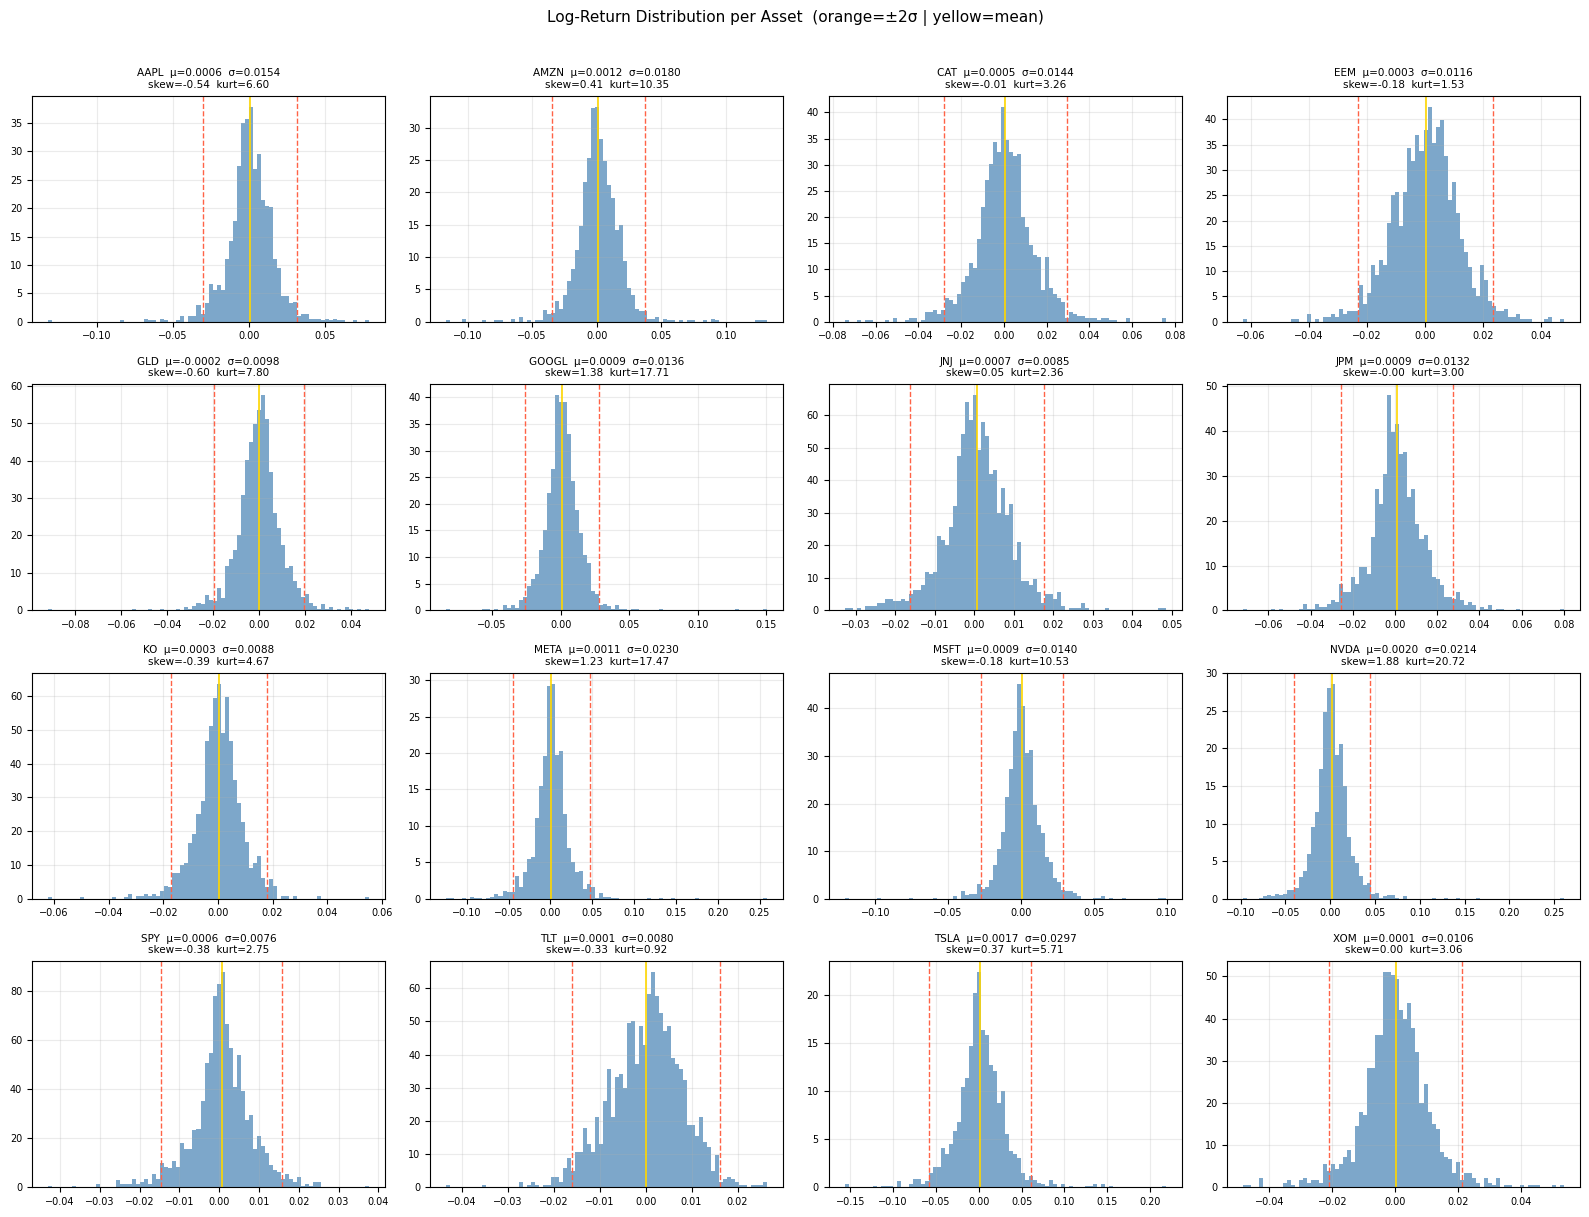

✓ v1_trial04_w5_d20_asset16_4.1_return_dist.png


In [11]:
close_train = splits["train"].xs("Close", axis=1, level=0)
log_ret      = np.log(close_train / close_train.shift(1)).dropna()

stats_df = pd.DataFrame({
    "Mean"    : log_ret.mean(),
    "Std"     : log_ret.std(),
    "Skew"    : log_ret.skew(),
    "Kurt"    : log_ret.kurt(),
    "Min"     : log_ret.min(),
    "Max"     : log_ret.max(),
    "Sharpe"  : log_ret.mean() / log_ret.std() * np.sqrt(252),
    "Ann.Ret" : log_ret.mean() * 252,
    "Ann.Vol" : log_ret.std()  * np.sqrt(252),
}).round(6)

stats_df.to_csv(atable("return_stats.csv"))
print(f"✓ {atable('return_stats.csv').name}")
print(stats_df.sort_values("Std", ascending=False).to_string())

n_assets = len(assets)
ncols = 4
nrows = math.ceil(n_assets / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, sym in enumerate(sorted(assets)):
    ax = axes[i]
    ret = log_ret[sym].dropna()
    mu, sigma = ret.mean(), ret.std()
    ax.hist(ret, bins=80, color="steelblue", alpha=0.7, density=True, edgecolor="none")
    ax.axvline(mu, color="gold", lw=1.2)
    for s in [1, -1]:
        ax.axvline(mu + s * 2 * sigma, color="tomato", lw=1, ls="--")
    ax.set_title(f"{sym}  μ={mu:.4f}  σ={sigma:.4f}\nskew={ret.skew():.2f}  kurt={ret.kurt():.2f}", fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Log-Return Distribution per Asset  (orange=±2σ | yellow=mean)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(aplot("4.1_return_dist.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.1_return_dist.png').name}")

## 4.2 Asset Return Correlation Heatmap

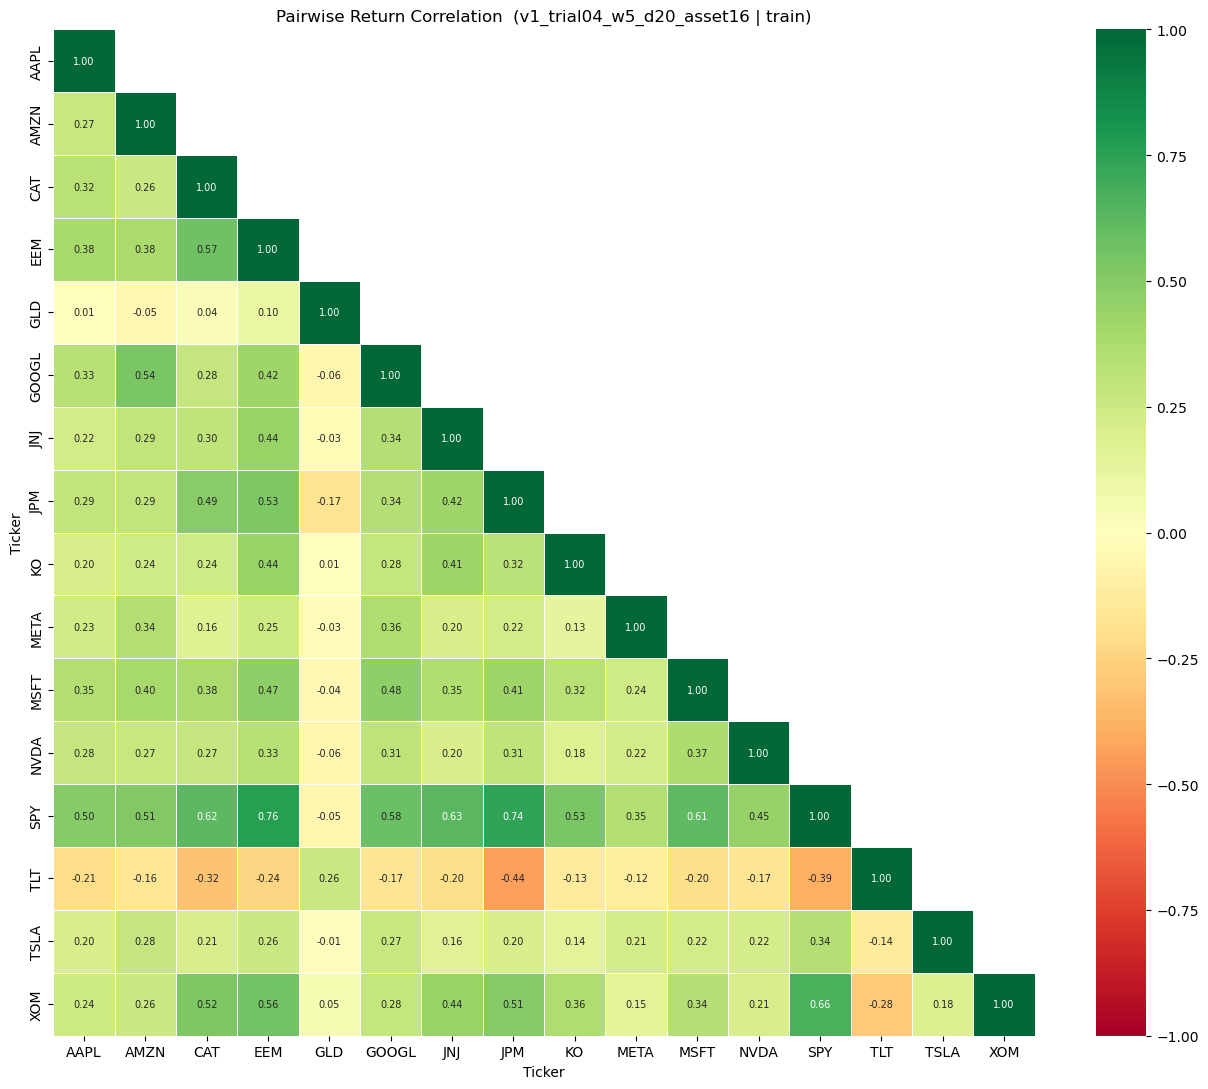

✓ v1_trial04_w5_d20_asset16_4.2_return_correlation.png

Highly correlated pairs (|r|>0.85): 0
  None found.


In [12]:
corr = log_ret.corr()
corr.to_csv(atable("return_correlation.csv"))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-1, vmax=1, center=0, linewidths=0.4, linecolor="white",
    annot_kws={"size": 7}, ax=ax,
)
ax.set_title(f"Pairwise Return Correlation  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.2_return_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.2_return_correlation.png').name}")

pairs = []
for i_a, a in enumerate(corr.columns):
    for j_a, b in enumerate(corr.columns):
        if j_a <= i_a:
            continue
        r = corr.loc[a, b]
        if abs(r) > 0.85:
            pairs.append({"Asset A": a, "Asset B": b, "r": round(r, 4)})

pairs_df = pd.DataFrame(pairs).sort_values("r", ascending=False) if pairs else pd.DataFrame(columns=["Asset A","Asset B","r"])
pairs_df.to_csv(atable("high_corr_pairs.csv"), index=False)
print(f"\nHighly correlated pairs (|r|>0.85): {len(pairs_df)}")
print(pairs_df.to_string(index=False) if not pairs_df.empty else "  None found.")

## 4.3 Rolling Volatility Regime

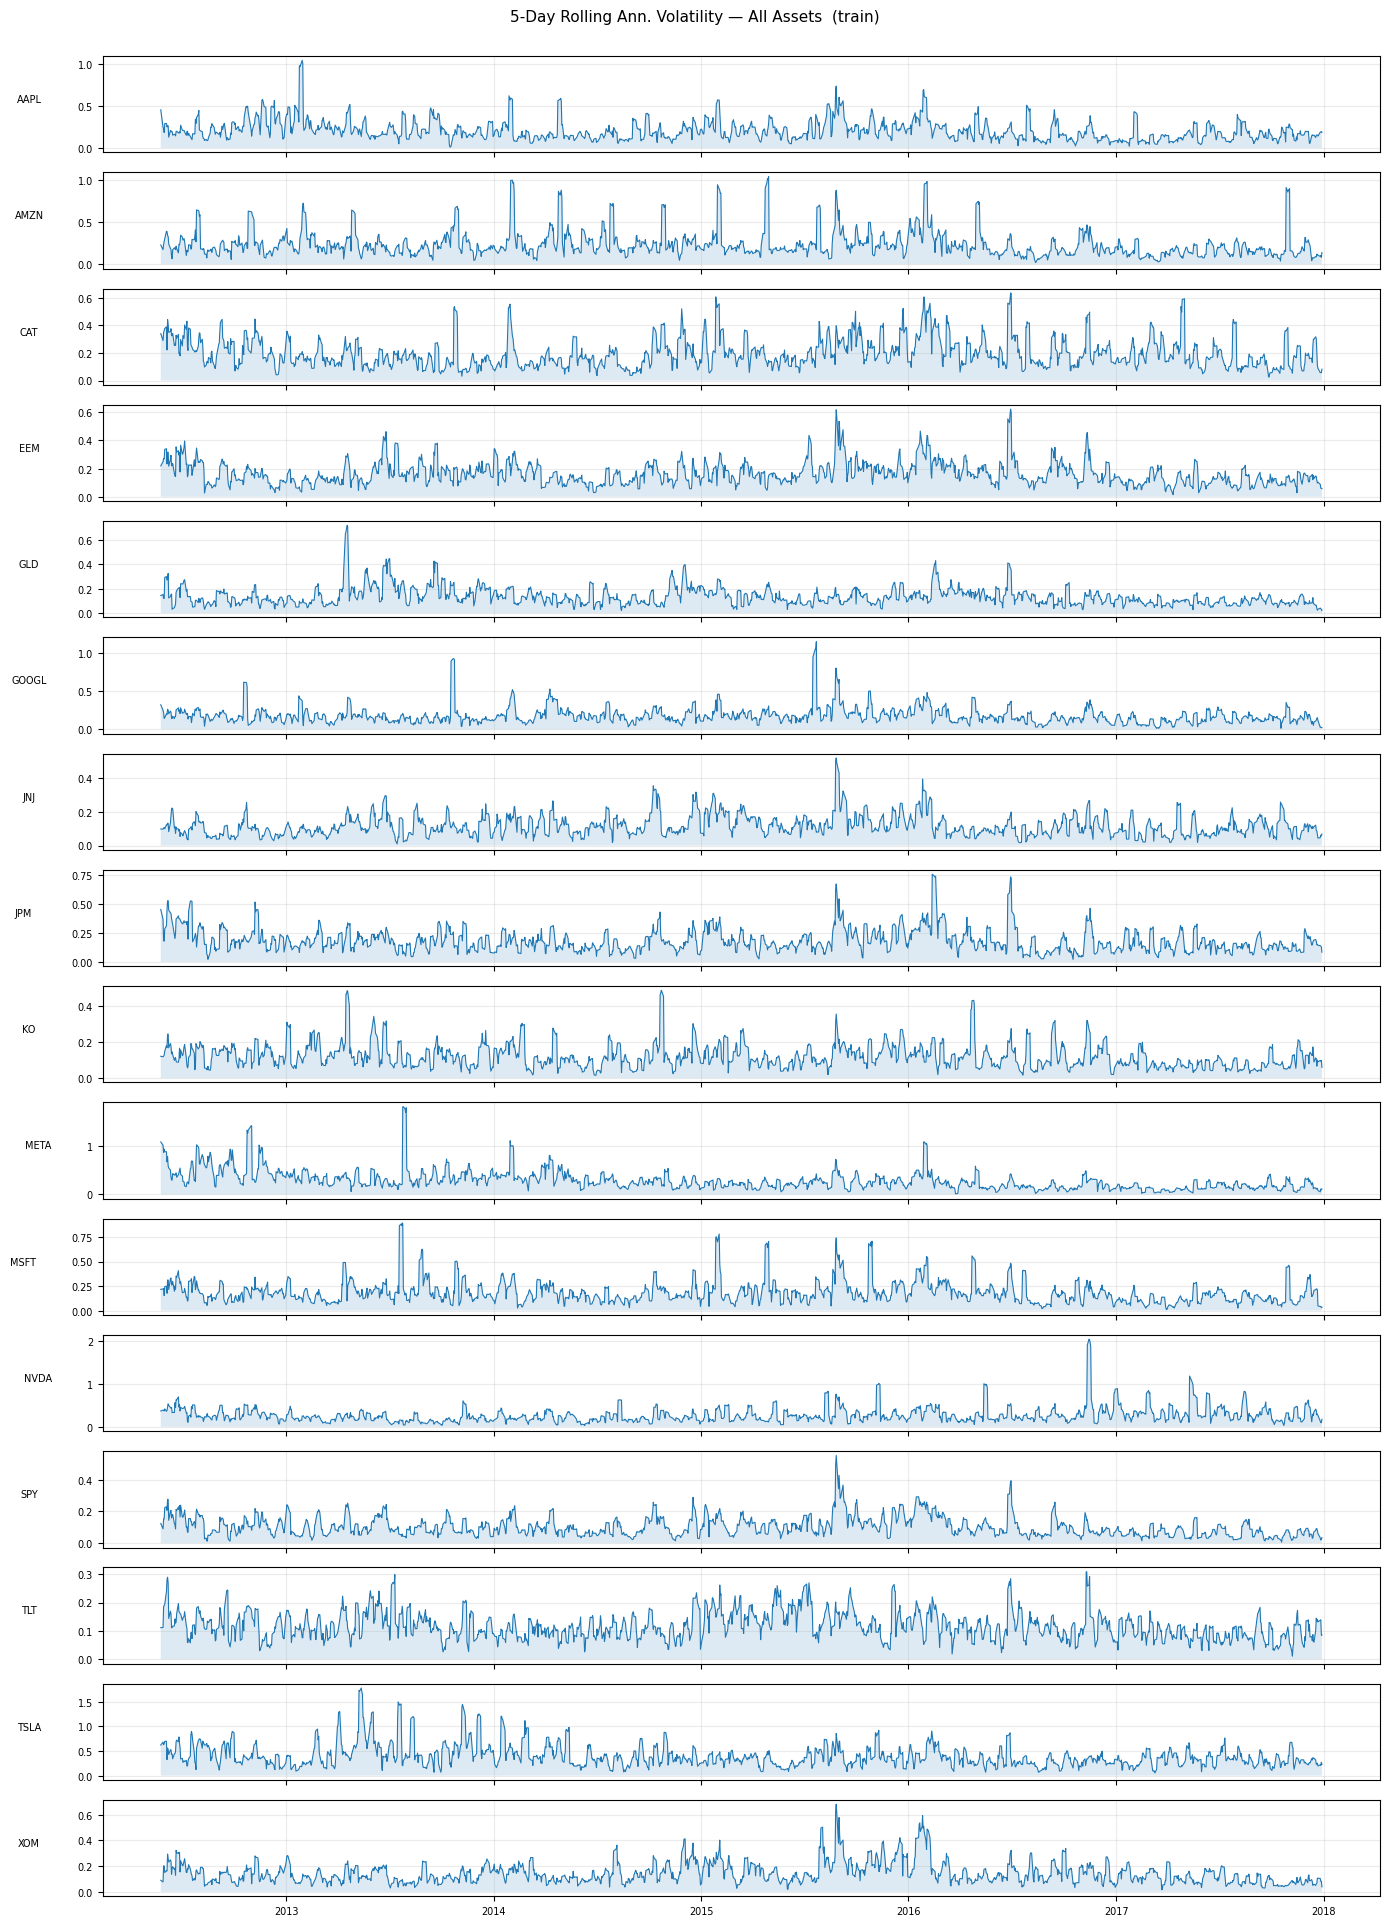

✓ v1_trial04_w5_d20_asset16_4.3_rolling_vol_per_asset.png
✓ v1_trial04_w5_d20_asset16_rolling_vol_summary.csv
        Mean_AnnVol  Max_AnnVol  Std_AnnVol
Ticker                                     
TSLA         0.4045      1.7825      0.2392
META         0.2919      1.8252      0.2105
NVDA         0.2804      2.0512      0.1941
AMZN         0.2400      1.0420      0.1613
AAPL         0.2100      1.0431      0.1244
CAT          0.1994      0.6347      0.1085
MSFT         0.1885      0.8926      0.1202
JPM          0.1849      0.7557      0.1016
GOOGL        0.1823      1.1521      0.1155
EEM          0.1659      0.6213      0.0827
XOM          0.1475      0.6805      0.0860
GLD          0.1360      0.7207      0.0771
KO           0.1223      0.4840      0.0690
JNJ          0.1192      0.5210      0.0643
TLT          0.1192      0.3083      0.0491
SPY          0.1045      0.5518      0.0632


In [13]:
roll_vol = log_ret.rolling(cfg.window_size).std() * np.sqrt(252)

fig, axes = plt.subplots(n_assets, 1, figsize=(14, max(8, n_assets * 1.2)), sharex=True)
for ax, sym in zip(axes, sorted(assets)):
    ax.plot(roll_vol.index, roll_vol[sym], lw=0.8)
    ax.fill_between(roll_vol.index, roll_vol[sym], alpha=0.15)
    ax.set_ylabel(sym, fontsize=7, rotation=0, labelpad=35)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

fig.suptitle(f"{cfg.window_size}-Day Rolling Ann. Volatility — All Assets  (train)", fontsize=11, y=1.001)
plt.tight_layout()
plt.savefig(aplot("4.3_rolling_vol_per_asset.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.3_rolling_vol_per_asset.png').name}")

vol_summary = pd.DataFrame({
    "Mean_AnnVol" : roll_vol.mean(),
    "Max_AnnVol"  : roll_vol.max(),
    "Std_AnnVol"  : roll_vol.std(),
}).round(4)
vol_summary.to_csv(atable("rolling_vol_summary.csv"))
print(f"✓ {atable('rolling_vol_summary.csv').name}")
print(vol_summary.sort_values("Mean_AnnVol", ascending=False).to_string())

## 4.4 Average Cross-Asset Volatility (Regime Indicator)

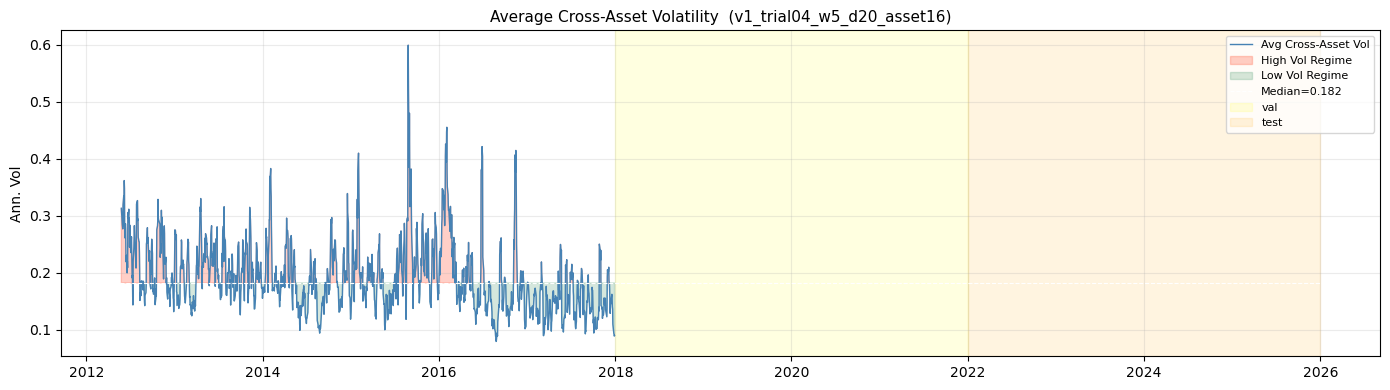

✓ v1_trial04_w5_d20_asset16_4.4_avg_vol_regime.png


In [14]:
avg_vol = roll_vol.mean(axis=1)
vol_median = avg_vol.median()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(avg_vol.index, avg_vol.values, lw=1, color="steelblue", label="Avg Cross-Asset Vol")
ax.fill_between(avg_vol.index, avg_vol.values, vol_median,
                where=(avg_vol.values > vol_median), color="tomato", alpha=0.3, label="High Vol Regime")
ax.fill_between(avg_vol.index, avg_vol.values, vol_median,
                where=(avg_vol.values <= vol_median), color="seagreen", alpha=0.2, label="Low Vol Regime")
ax.axhline(vol_median, color="white", lw=0.8, ls="--", label=f"Median={vol_median:.3f}")

# shade val & test periods
for period, color, label in [
    (cfg.val_period,  "yellow", "val"),
    (cfg.test_period, "orange", "test"),
]:
    ax.axvspan(pd.Timestamp(period[0]), pd.Timestamp(period[1]),
               alpha=0.12, color=color, label=label)

ax.set_title(f"Average Cross-Asset Volatility  ({cfg.name})", fontsize=11)
ax.set_ylabel("Ann. Vol")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(aplot("4.4_avg_vol_regime.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.4_avg_vol_regime.png').name}")

## 4.5 Feature Distribution per Indicator

✓ v1_trial04_w5_d20_asset16_feature_stats.csv
                                      mean       std       min       max      skew       kurt
ATR_14_minmax                     0.451529  0.383824  0.000000  1.000000  0.161026  -1.551913
BBANDS_lowerband_distance_close   0.049762  0.050679 -0.082651  0.636502  2.854675  16.002558
BBANDS_middleband_distance_close  0.005885  0.036569 -0.382136  0.364294 -0.064663   8.240386
BBANDS_upperband_distance_close  -0.037992  0.046479 -0.747427  0.128196 -3.418623  23.404055
MACD_macd                         0.205826  0.766951 -5.404873  4.572471  0.054442   4.192748
MACD_macdhist                     0.001062  0.235272 -2.282430  2.385152 -0.060568   6.919059
MACD_macdsignal                   0.204764  0.719166 -4.344673  4.129895  0.105563   3.732242
ROC_10_minmax                     0.484350  0.382914  0.000000  1.000000  0.066543  -1.547607
RSI_14_minmax                     0.516822  0.361105  0.000000  1.000000 -0.061056  -1.433451
weekday_cos   

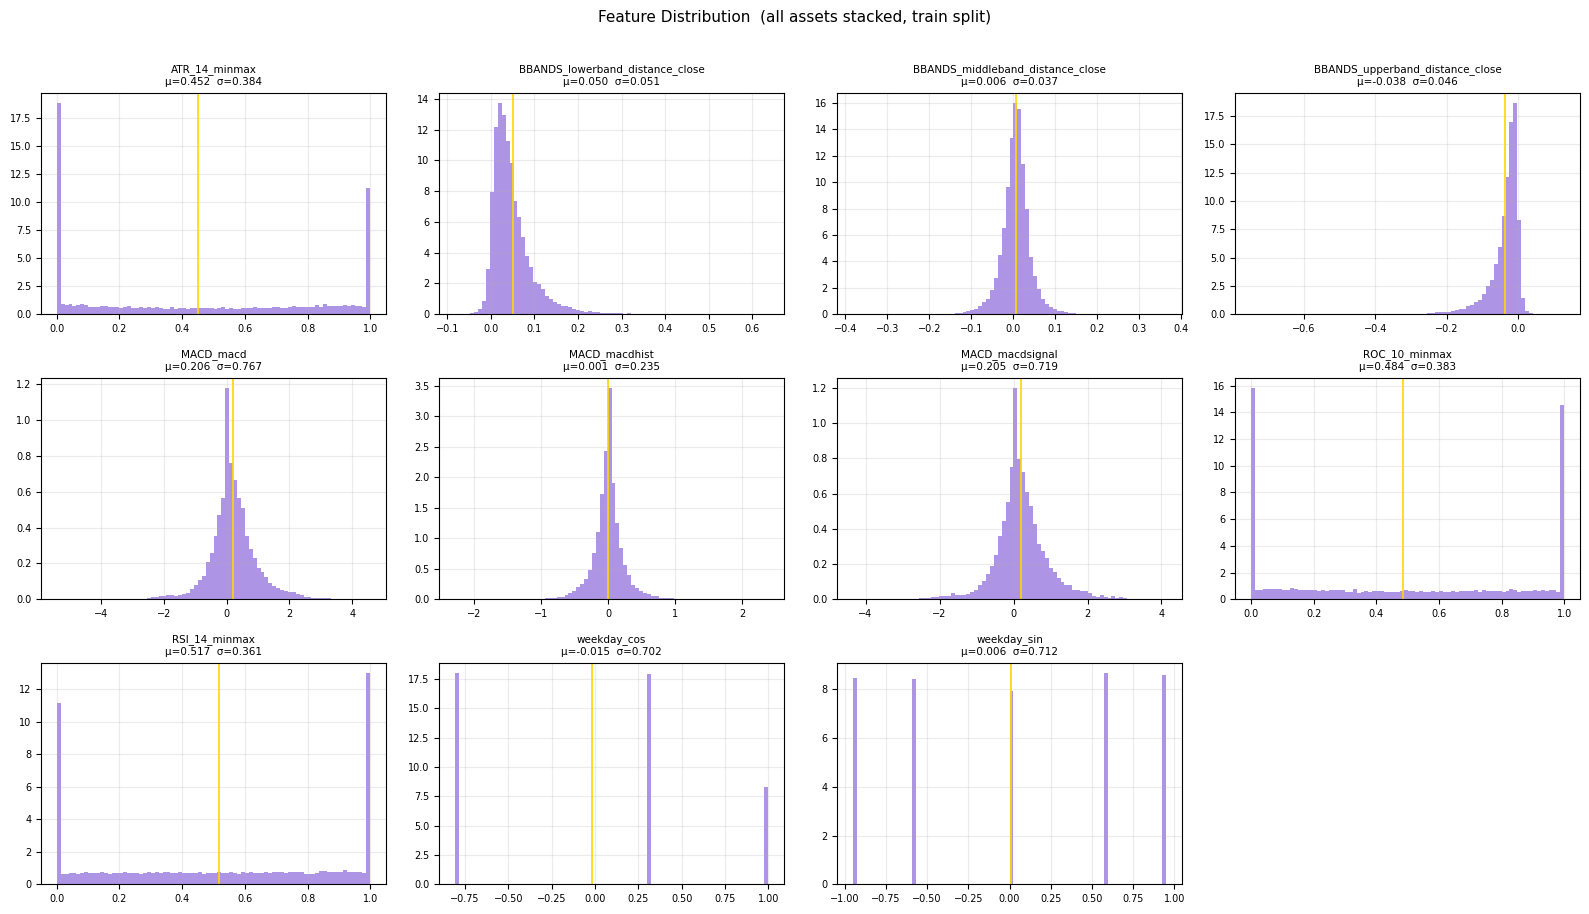

✓ v1_trial04_w5_d20_asset16_4.5_feature_distributions.png


In [15]:
feat_cols_check = feat_splits["train"].xs(assets[0], axis=1, level=1).columns.tolist()

feat_stacked = np.concatenate(
    [feat_splits["train"].xs(sym, axis=1, level=1).values for sym in assets], axis=0
)
feat_stacked_df = pd.DataFrame(feat_stacked, columns=feat_cols_check)

feat_stats = feat_stacked_df.describe().T
feat_stats["skew"] = feat_stacked_df.skew()
feat_stats["kurt"] = feat_stacked_df.kurt()
feat_stats = feat_stats.round(6)
feat_stats.to_csv(atable("feature_stats.csv"))
print(f"✓ {atable('feature_stats.csv').name}")
print(feat_stats[["mean","std","min","max","skew","kurt"]].to_string())

n_feats = len(feat_cols_check)
ncols_f = 4
nrows_f = math.ceil(n_feats / ncols_f)

fig, axes = plt.subplots(nrows_f, ncols_f, figsize=(ncols_f * 4, nrows_f * 3))
axes = axes.flatten()

for i, col in enumerate(feat_cols_check):
    ax   = axes[i]
    vals = feat_stacked_df[col].dropna()
    ax.hist(vals, bins=80, color="mediumpurple", alpha=0.75, density=True, edgecolor="none")
    ax.axvline(vals.mean(), color="gold", lw=1.2)
    ax.set_title(f"{col}\nμ={vals.mean():.3f}  σ={vals.std():.3f}", fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distribution  (all assets stacked, train split)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(aplot("4.5_feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.5_feature_distributions.png').name}")

## 4.6 Feature × Feature Correlation

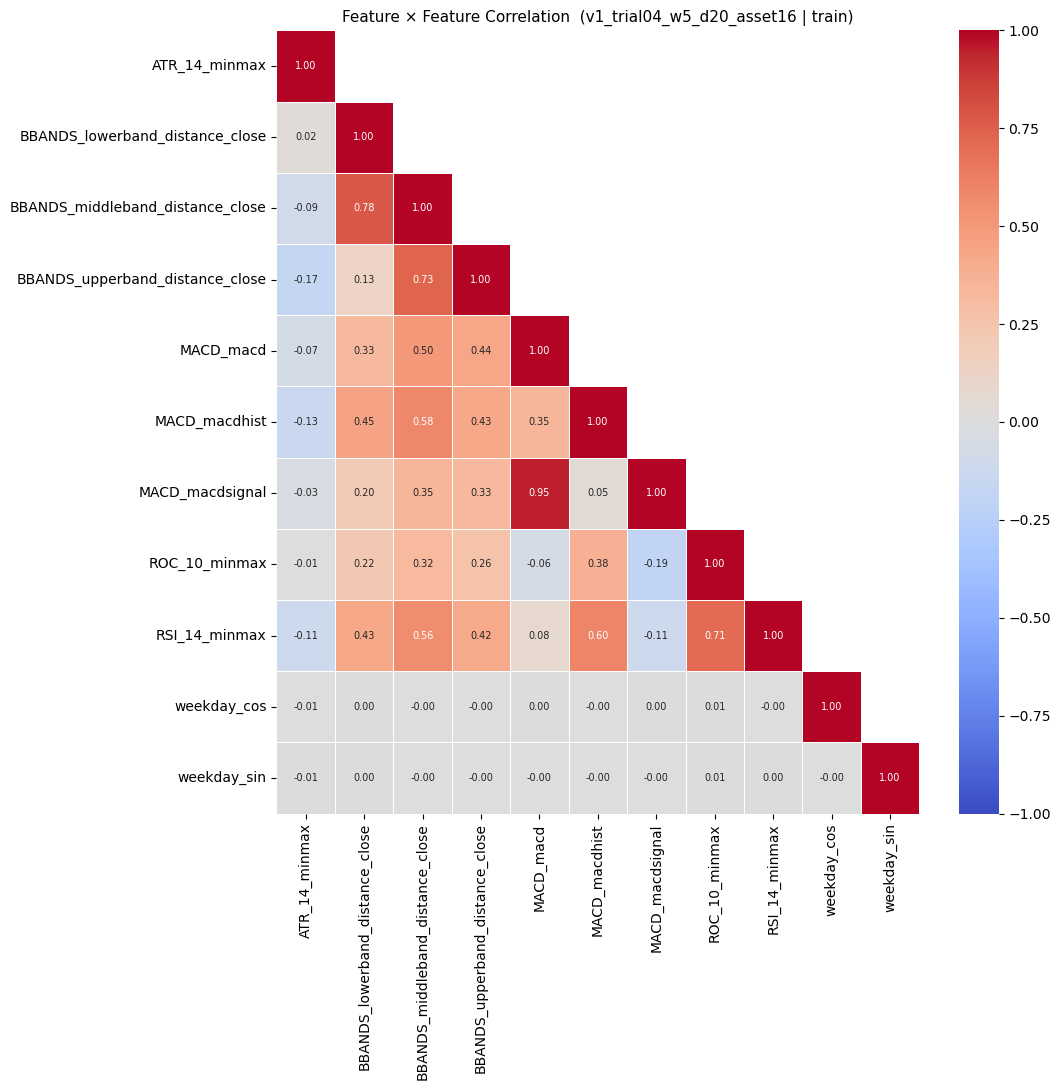

✓ v1_trial04_w5_d20_asset16_4.6_feature_correlation.png


In [16]:
feat_corr = feat_stacked_df.corr()
feat_corr.to_csv(atable("feature_correlation.csv"))

mask_f = np.triu(np.ones_like(feat_corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(max(10, n_feats), max(8, n_feats)))
sns.heatmap(
    feat_corr, mask=mask_f, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0, linewidths=0.4, linecolor="white",
    annot_kws={"size": 7}, ax=ax,
)
ax.set_title(f"Feature × Feature Correlation  ({cfg.name} | train)", fontsize=11)
plt.tight_layout()
plt.savefig(aplot("4.6_feature_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.6_feature_correlation.png').name}")

## 4.7 Feature vs Next-Day Return (Predictive Correlation)

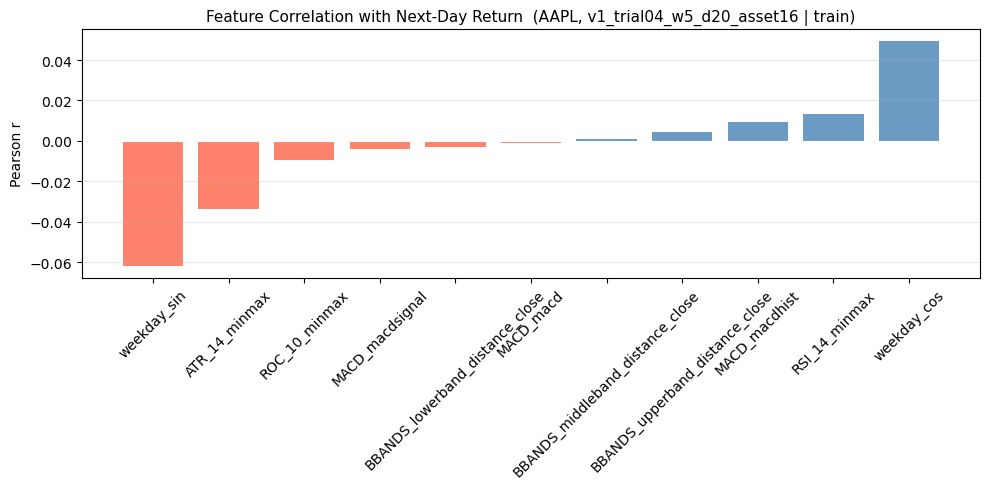

✓ v1_trial04_w5_d20_asset16_4.7_feature_corr_nextday_AAPL.png


In [17]:
rep_sym  = "AAPL" if "AAPL" in assets else assets[0]
feat_rep = feat_splits["train"].xs(rep_sym, axis=1, level=1).copy()
ret_1d   = log_ret[[rep_sym]].rename(columns={rep_sym: "ret_1d"})
merged   = feat_rep.join(ret_1d.shift(-1)).dropna()
pred_corr = merged.corr()["ret_1d"].drop("ret_1d").sort_values()

pred_corr_df = pred_corr.reset_index()
pred_corr_df.columns = ["feature", "pearson_r"]
pred_corr_df.to_csv(atable(f"predictive_corr_{rep_sym}.csv"), index=False)

fig, ax = plt.subplots(figsize=(max(10, len(pred_corr) * 0.7), 5))
colors = ["tomato" if v < 0 else "steelblue" for v in pred_corr.values]
ax.bar(pred_corr.index, pred_corr.values, color=colors, alpha=0.8, edgecolor="none")
ax.axhline(0, color="white", lw=0.8)
ax.set_title(f"Feature Correlation with Next-Day Return  ({rep_sym}, {cfg.name} | train)", fontsize=11)
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(aplot(f"4.7_feature_corr_nextday_{rep_sym}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot(f'4.7_feature_corr_nextday_{rep_sym}.png').name}")

## 4.8  PCA — Feature Importance & Market Mode

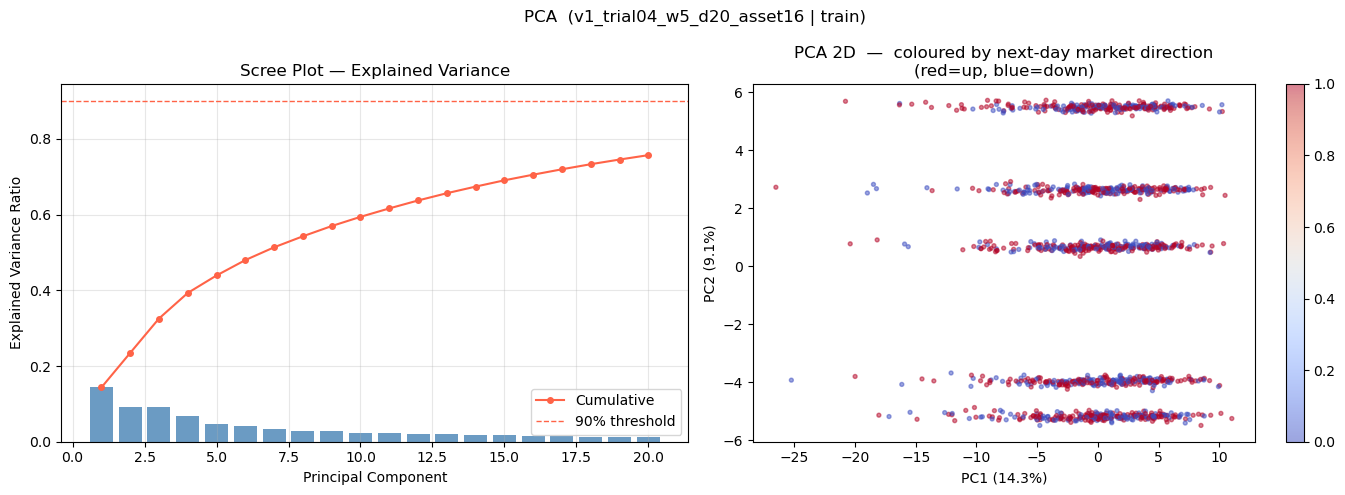

✓ v1_trial04_w5_d20_asset16_4.8_pca.png

  Components for 90% variance : 41  (out of 176)
  PC1 explains               : 14.3%
  Top PC1 feature            : SPY_BBANDS_middleband_distance_close

  Top-10 loadings on PC1:
SPY_BBANDS_middleband_distance_close    0.184031
SPY_MACD_macdhist                       0.165662
SPY_BBANDS_upperband_distance_close     0.151276
SPY_BBANDS_lowerband_distance_close     0.145228
EEM_BBANDS_middleband_distance_close    0.140184
SPY_RSI_14_minmax                       0.136835
CAT_BBANDS_middleband_distance_close    0.134810
EEM_BBANDS_upperband_distance_close     0.131413
SPY_MACD_macd                           0.128952
JPM_BBANDS_middleband_distance_close    0.128056


In [18]:
frames = []
for s in sorted(assets):
    fd = feat_splits["train"].xs(s, axis=1, level=1).copy().dropna()
    fd.columns = [f"{s}_{c}" for c in fd.columns]
    frames.append(fd)

X_all = pd.concat(frames, axis=1).dropna()

# label: next-day avg market return direction
y_all = (log_ret.reindex(X_all.index).mean(axis=1).shift(-1) > 0).astype(int).reindex(X_all.index).dropna()
X_all = X_all.reindex(y_all.index)

sk_scaler = SKStandardScaler()
X_sc      = sk_scaler.fit_transform(X_all)

pca_full = PCA().fit(X_sc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n90      = int(np.argmax(cum_var >= 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color="steelblue", alpha=0.8)
axes[0].plot(range(1, 21), cum_var[:20], color="tomato", marker="o", ms=4, label="Cumulative")
axes[0].axhline(0.90, color="tomato", ls="--", lw=1, label="90% threshold")
axes[0].set_title("Scree Plot — Explained Variance")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].legend()
axes[0].grid(alpha=0.3)

pca2    = PCA(n_components=2).fit_transform(X_sc)
sc_pca  = axes[1].scatter(pca2[:, 0], pca2[:, 1], c=y_all.values, cmap="coolwarm", alpha=0.5, s=8)
axes[1].set_title("PCA 2D  —  coloured by next-day market direction\n(red=up, blue=down)")
axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc_pca, ax=axes[1])
fig.suptitle(f"PCA  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.8_pca.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.8_pca.png').name}")

loadings = pd.Series(np.abs(pca_full.components_[0]), index=X_all.columns).sort_values(ascending=False)
loadings.head(20).rename("loading").to_frame().to_csv(atable("pca_loadings.csv"))
pd.DataFrame([{
    "n_components_90pct": n90,
    "total_features"    : X_all.shape[1],
    "pc1_explained_var" : pca_full.explained_variance_ratio_[0],
    "top_feature_pc1"   : loadings.index[0],
}]).to_csv(atable("pca_summary.csv"), index=False)

print(f"\n  Components for 90% variance : {n90}  (out of {X_all.shape[1]})")
print(f"  PC1 explains               : {pca_full.explained_variance_ratio_[0]:.1%}")
print(f"  Top PC1 feature            : {loadings.index[0]}")
print(f"\n  Top-10 loadings on PC1:")
print(loadings.head(10).to_string())

## 4.9  t-SNE — Market Regime Clustering

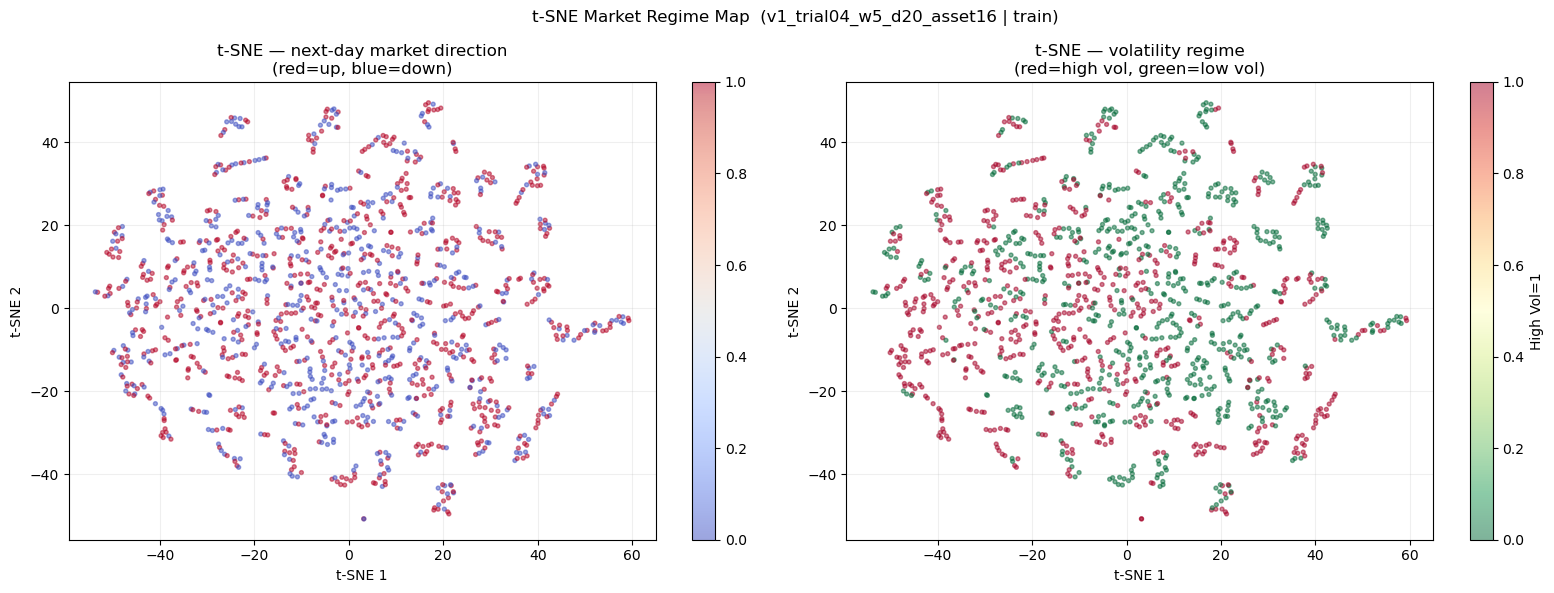

✓ v1_trial04_w5_d20_asset16_4.9_tsne.png


In [19]:
roll_vol_aligned = (log_ret.rolling(cfg.window_size).std() * np.sqrt(252)).mean(axis=1)
vol_regime       = (roll_vol_aligned > roll_vol_aligned.median()).astype(int).reindex(y_all.index)

X_pca_n90 = PCA(n_components=min(n90, 50)).fit_transform(X_sc)

tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=cfg.random_seed)
X_tsne = tsne.fit_transform(X_pca_n90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all.values,
                      cmap="coolwarm", alpha=0.5, s=8)
axes[0].set_title("t-SNE — next-day market direction\n(red=up, blue=down)")
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=vol_regime.reindex(y_all.index).values,
                      cmap="RdYlGn_r", alpha=0.5, s=8)
axes[1].set_title("t-SNE — volatility regime\n(red=high vol, green=low vol)")
plt.colorbar(sc2, ax=axes[1], label="High Vol=1")

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(alpha=0.2)

fig.suptitle(f"t-SNE Market Regime Map  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.9_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.9_tsne.png').name}")

## 4.10 UMAP — Global Structure

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


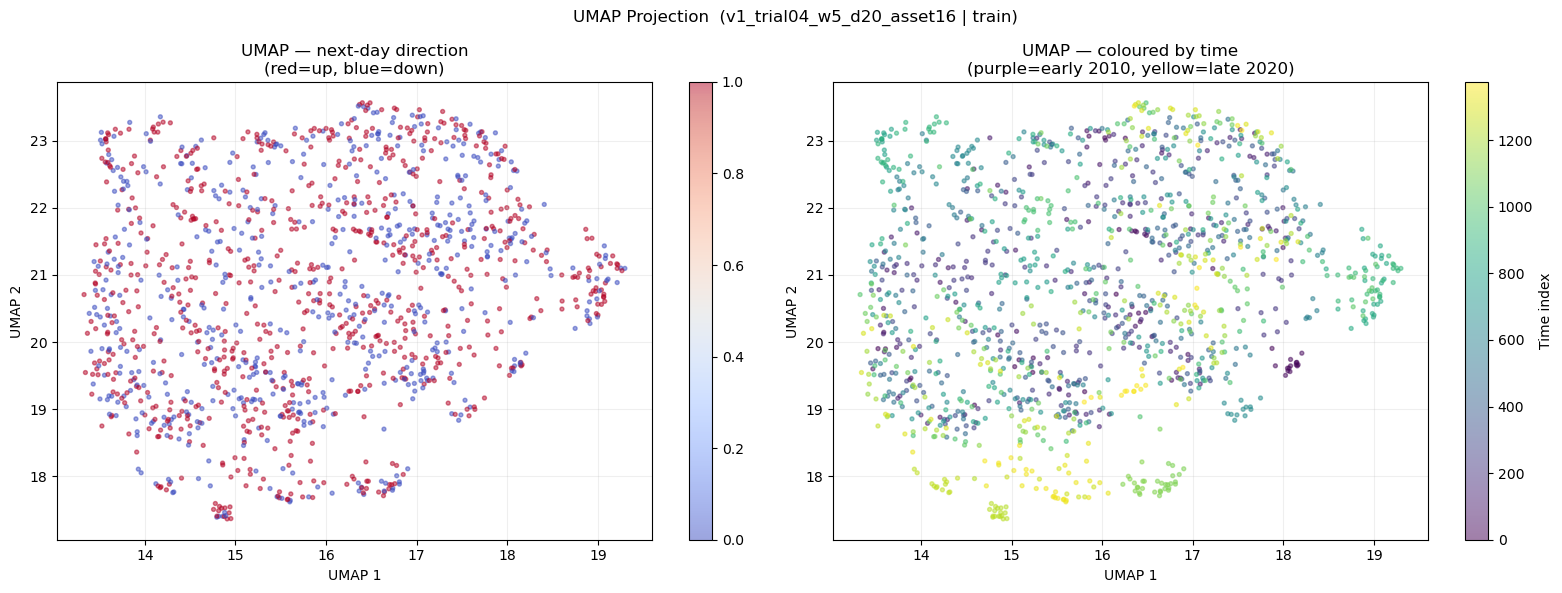

✓ v1_trial04_w5_d20_asset16_4.10_umap.png


In [20]:
reducer = umap_lib.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                         random_state=cfg.random_seed)
X_umap  = reducer.fit_transform(X_pca_n90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y_all.values,
                      cmap="coolwarm", alpha=0.5, s=8)
axes[0].set_title("UMAP — next-day direction\n(red=up, blue=down)")
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=np.arange(len(X_umap)),
                      cmap="viridis", alpha=0.5, s=8)
axes[1].set_title("UMAP — coloured by time\n(purple=early 2010, yellow=late 2020)")
plt.colorbar(sc2, ax=axes[1], label="Time index")

for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(alpha=0.2)

fig.suptitle(f"UMAP Projection  ({cfg.name} | train)", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4.10_umap.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4.10_umap.png').name}")

## 4.11 Raw Data Export

In [21]:
for split_name, df_feat_s in feat_splits.items():
    df_flat = df_feat_s.copy()
    df_flat.columns = [f"{sym}_{feat}" for feat, sym in df_flat.columns]
    path = atable(f"features_raw_{split_name}.csv")
    df_flat.to_csv(path)
    print(f"✓ {path.name}  shape={df_flat.shape}")

for split_name, df_s in splits.items():
    close_s  = df_s.xs("Close", axis=1, level=0)
    logret_s = np.log(close_s / close_s.shift(1)).dropna()
    path = atable(f"log_returns_{split_name}.csv")
    logret_s.to_csv(path)
    print(f"✓ {path.name}  shape={logret_s.shape}")

✓ v1_trial04_w5_d20_asset16_features_raw_train.csv  shape=(1376, 192)
✓ v1_trial04_w5_d20_asset16_features_raw_val.csv  shape=(969, 192)
✓ v1_trial04_w5_d20_asset16_features_raw_test.csv  shape=(964, 192)
✓ v1_trial04_w5_d20_asset16_log_returns_train.csv  shape=(1413, 16)
✓ v1_trial04_w5_d20_asset16_log_returns_val.csv  shape=(1006, 16)
✓ v1_trial04_w5_d20_asset16_log_returns_test.csv  shape=(1001, 16)


## 4.12 Summary

In [22]:
print("=" * 65)
print(f"  SECTION 4 — DATA ANALYSIS SUMMARY  [{cfg.name}]")
print("=" * 65)

print(f"\n  Assets  : {len(assets)}  →  {sorted(assets)}")
print(f"  Train   : {len(log_ret)} days")

print(f"\n[Return Stats]")
print(f"  Most volatile  : {stats_df['Std'].idxmax():<6}  σ={stats_df['Std'].max():.4f}")
print(f"  Least volatile : {stats_df['Std'].idxmin():<6}  σ={stats_df['Std'].min():.4f}")
print(f"  Best Sharpe    : {stats_df['Sharpe'].idxmax():<6}  SR={stats_df['Sharpe'].max():.3f}")

print(f"\n[Correlation]")
print(f"  High-corr pairs (|r|>0.85) : {len(pairs_df)}")

print(f"\n[Features]  {len(feat_cols_check)} features/asset")
for col in feat_cols_check:
    mu  = feat_stats.loc[col, "mean"]
    std = feat_stats.loc[col, "std"]
    sk  = feat_stats.loc[col, "skew"]
    print(f"  {col:<45}  μ={mu:+.4f}  σ={std:.4f}  skew={sk:+.3f}")

print(f"\n[PCA]")
print(f"  PC1 explains    : {pca_full.explained_variance_ratio_[0]:.1%}")
print(f"  Components@90%  : {n90}  (out of {X_all.shape[1]})")
print(f"  Top PC1 feature : {loadings.index[0]}")

print(f"\n[Output]")
print(f"  Plots  → {analysis_plots_dir}")
print(f"  Tables → {tables_dir}")
print(f"\n✓ Section 4 complete")


  SECTION 4 — DATA ANALYSIS SUMMARY  [v1_trial04_w5_d20_asset16]

  Assets  : 16  →  ['AAPL', 'AMZN', 'CAT', 'EEM', 'GLD', 'GOOGL', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'SPY', 'TLT', 'TSLA', 'XOM']
  Train   : 1413 days

[Return Stats]
  Most volatile  : TSLA    σ=0.0297
  Least volatile : SPY     σ=0.0076
  Best Sharpe    : NVDA    SR=1.494

[Correlation]
  High-corr pairs (|r|>0.85) : 0

[Features]  11 features/asset
  ATR_14_minmax                                  μ=+0.4515  σ=0.3838  skew=+0.161
  BBANDS_lowerband_distance_close                μ=+0.0498  σ=0.0507  skew=+2.855
  BBANDS_middleband_distance_close               μ=+0.0059  σ=0.0366  skew=-0.065
  BBANDS_upperband_distance_close                μ=-0.0380  σ=0.0465  skew=-3.419
  MACD_macd                                      μ=+0.2058  σ=0.7670  skew=+0.054
  MACD_macdhist                                  μ=+0.0011  σ=0.2353  skew=-0.061
  MACD_macdsignal                                μ=+0.2048  σ=0.7192  skew=+0.

In [23]:
SPLIT_COLORS  = {"train": "steelblue", "val": "gold", "test": "tomato"}
SPLIT_ALPHA   = {"train": 0.5,         "val": 0.6,    "test": 0.7}
CH_NAMES      = ["Close_logret", "High_logret", "Low_logret", "Vol_logret"]

# 5. Data Array Shape & Sequences
| Symbol | Axis | Meaning |
|--------|------|---------|
| T | 0 | Time (number of windows) |
| A | 1 | Assets |
| W | 2 | Window size |
| C | 3 | Channels (OHLCV log-diffs) |
| D | 3/4 | Sequence depth |
| F | 3 | Feature count |

* T = Time (Num of Windows),
* A = Assets,
* W = Window size,
* C = Channels,
* D = Sequence Depth

## 5.1 Build x  [T, A, W, C]

In [24]:
def build_x(df_raw: pd.DataFrame, assets: list, cfg, stride: int = 1) -> np.ndarray:
    """
    Build x from raw OHLCV using sliding window.

    Steps:
      1. log diff per channel (Close, High, Low, Volume)
      2. sliding window of size W

    Output: [T, A, W, C]
      T = number of windows
      A = assets
      W = window_size
      C = 4  (logdiff_close, logdiff_high, logdiff_low, logdiff_volume)
    """
    channels = ["Close", "High", "Low", "Volume"]
    W = cfg.window_size

    # ── step 1: log diff per asset [T_total, A, C] ────────────────────────
    parts = []
    for sym in assets:
        ohlcv = df_raw.loc[:, df_raw.columns.get_level_values(1) == sym].copy()
        ohlcv.columns = ohlcv.columns.get_level_values(0)
        ld = pd.DataFrame(
            {ch: np.log(ohlcv[ch] / ohlcv[ch].shift(1)) for ch in channels},
            index=df_raw.index,
        )
        parts.append(ld)

    # stack → [T_total, A, C]
    ld_vals = np.stack([p.values for p in parts], axis=1)
    dates   = df_raw.index.to_numpy()

    # drop first row (NaN from log diff)
    ld_vals = ld_vals[1:]
    dates   = dates[1:]

    # ── step 2: sliding window [T, A, W, C] ───────────────────────────────
    T_total = len(dates)
    # n_windows = T_total - W + 1
    n_windows = (T_total - W) // stride

    x      = np.stack([ld_vals[i: i + W] for i in range(n_windows)], axis=0)
    # x shape: [n_windows, W, A, C] → transpose → [n_windows, A, W, C]
    x      = x.transpose(0, 2, 1, 3)
    # w_dates = np.stack([dates[i: i + W] for i in range(n_windows)], axis=0)  # [T, W]
    w_dates = np.stack([
        dates[i+1: i+1+W] for i in range(0, n_windows * stride, stride)
    ])

    return x, w_dates

## 5.2 Create Sequence (x)

In [25]:
def create_seq(x: np.ndarray, D: int) -> np.ndarray:
    """
    Expand x with backward sequence dimension D.

    Input  : [T, A, W, C]
    Output : [T, A, W, D, C]   if D > 0
             [T, A, W, C]      if D = 0  (no-op)

    x[t, a, w, d, c] = log_diff of asset a, channel c,
                       at step (w - d) relative to window position w
    """
    if D == 0:
        return x   # squeeze — no seq

    T, A, W, C = x.shape
    # pad left with zeros สำหรับ d ที่ย้อนหลังเกิน
    x_padded = np.concatenate(
        [np.zeros((T, A, D, C)), x], axis=2   # [T, A, D+W, C]
    )

    # stack D shifts: d=0 คือ step ปัจจุบัน, d=1 คือย้อนหลัง 1, ...
    seq = np.stack(
        [x_padded[:, :, D - d: D - d + W, :] for d in range(D)],
        axis=3   # → [T, A, W, D, C]
    )

    return seq

In [26]:
x_base, w_dates = build_x(df_train, assets, cfg)
print(f"x_base  : {x_base.shape}")    # [T, A, W, C]
print(f"w_dates : {w_dates.shape}")   # [T, W]

# ── create_seq ─────────────────────────────────────────────────────────────
x_seq = create_seq(x_base, D=cfg.sequence_depth)
print(f"x_seq   : {x_seq.shape}")
# D>0 → [T, A, W, D, C]
# D=0 → [T, A, W, C]

x_base  : (1408, 16, 5, 4)
w_dates : (1408, 5)
x_seq   : (1408, 16, 5, 20, 4)


## 5.3  `build_x` → `[T, A, W, C]`

In [27]:
def build_x(df_raw: pd.DataFrame, assets: list, cfg, stride: int = 1):
    channels  = ["Close", "High", "Low", "Volume"]
    W         = cfg.window_size

    # ── raw values [T_total, A, C] ─────────────────────────────────────────
    raw_vals = np.stack([
        df_raw.loc[:, df_raw.columns.get_level_values(1) == sym]
              .copy()
              .set_axis(df_raw.columns.get_level_values(0)[
                  df_raw.columns.get_level_values(1) == sym], axis=1
              )[channels].values
        for sym in assets
    ], axis=1)                                         # [T_total, A, C]

    # ── log diff [T_total-1, A, C] ─────────────────────────────────────────
    ld_vals = np.log(raw_vals[1:] / (raw_vals[:-1] + 1e-8))
    dates   = df_raw.index.to_numpy()[1:]              # align กับ log diff

    T_total   = len(ld_vals)
    # n_windows = T_total - W                            # -W เพราะต้องมี init 1 step ก่อน window
    n_windows = (T_total - W) // stride

    x_list          = []
    ohlcv_raw_list  = []
    init_price_list = []
    init_date_list  = []

    for i in range(0, n_windows * stride, stride):
        init_idx = i                                   # step ก่อน window
        w_start  = i + 1
        w_end    = i + 1 + W

        # x  [A, W, C]
        x_w = ld_vals[w_start:w_end].transpose(1, 0, 2)

        # ohlcv_raw  [A, W, 4]
        ohlcv_w = raw_vals[w_start+1 : w_end+1].transpose(1, 0, 2)

        # init_price  [A]  — Close ก่อน window (index 0 ของ channels = Close)
        init_price_list.append(raw_vals[init_idx, :, 0])
        # init_price_list.append(raw_vals[w_start, :, 0])

        # init_date  scalar
        init_date_list.append(dates[init_idx])

        x_list.append(x_w)
        ohlcv_raw_list.append(ohlcv_w)

    x          = np.stack(x_list)           # [T, A, W, C]
    ohlcv_raw  = np.stack(ohlcv_raw_list)   # [T, A, W, 4]
    init_price = np.stack(init_price_list)  # [T, A]
    init_date  = np.array(init_date_list)   # [T]
    # w_dates    = np.stack([
    #     dates[i+1: i+1+W] for i in range(n_windows)
    # ])                                      # [T, W]
    w_dates = np.stack([
        dates[i+1: i+1+W] for i in range(0, n_windows * stride, stride)
    ])


    return x, w_dates, init_price, init_date, ohlcv_raw

## 5.4  `build_cond` → `[T, A, W, F]`

In [28]:
def build_cond(df_feat: pd.DataFrame, assets: list, cfg, stride: int = 1) -> np.ndarray:
    """
    Build cond from feature DataFrame using sliding window.

    Output: [T, A, W, F]
      T = number of windows (must match build_x)
      A = assets
      W = window_size
      F = features per asset (indicators + cyclical + log_return)
    """
    W = cfg.window_size

    lvl0_samples = df_feat.columns.get_level_values(0).unique()
    lvl1_samples = df_feat.columns.get_level_values(1).unique()

    if assets[0] in lvl1_samples:
        asset_level = 1
    elif assets[0] in lvl0_samples:
        asset_level = 0
    else:
        raise ValueError(
            f"Asset '{assets[0]}' not found in either MultiIndex level.\n"
            f"  level 0: {list(lvl0_samples)[:5]}\n"
            f"  level 1: {list(lvl1_samples)[:5]}"
        )


    # check avaliable assets
    available = df_feat.columns.get_level_values(asset_level).unique().tolist()
    missing   = [s for s in assets if s not in available]
    if missing:
        raise ValueError(
            f"build_cond: assets missing from df_feat columns: {missing}\n"
            f"  Available: {available}"
        )

    # ── [T_total, A, F] ───────────────────────────────────────────────────
    cond_vals = np.stack(
        [df_feat.xs(sym, axis=1, level=asset_level).values for sym in assets],
        axis=1
    )
    T_total = len(cond_vals)
    # n_windows = T_total - W + 1
    n_windows = (T_total - W) // stride

    if n_windows <= 0:
        raise ValueError(
            f"build_cond: not enough rows ({T_total}) for window_size={W}. "
            f"Need at least {W+1} rows."
        )

    # sliding window → [T, W, A, F] → [T, A, W, F]
    # cond = np.stack(
    #     [cond_vals[i: i + W] for i in range(n_windows)], axis=0
    # ).transpose(0, 2, 1, 3)
    cond = np.stack(
        [cond_vals[i: i + W] for i in range(0, n_windows * stride, stride)],
        axis=0
    ).transpose(0, 2, 1, 3)


    return cond

In [29]:
cond = build_cond(df_feat_train, assets, cfg)
print(f"cond : {cond.shape}")    # [T, A, W, F]

cond : (1371, 16, 5, 11)


In [30]:
T_x    = x_base.shape[0]
T_cond = cond.shape[0]
T      = min(T_x, T_cond)

x_base  = x_base[-T:]
x_seq   = create_seq(x_base, D=cfg.sequence_depth)
cond    = cond[-T:]
w_dates = w_dates[-T:]

print(f"aligned → x={x_seq.shape}  cond={cond.shape}  dates={w_dates.shape}")

aligned → x=(1371, 16, 5, 20, 4)  cond=(1371, 16, 5, 11)  dates=(1371, 5)


## 5.5 Pipeline & Run

In [31]:
x_base, w_dates, init_price, init_date, ohlcv_raw = build_x(df_train, assets, cfg)

x_seq = create_seq(x_base, D=cfg.sequence_depth)

# align T กับ cond
cond = build_cond(df_feat_train, assets, cfg)
T    = min(x_seq.shape[0], cond.shape[0])

x_seq      = x_seq[-T:]
cond       = cond[-T:]
w_dates    = w_dates[-T:]
init_price = init_price[-T:]
init_date  = init_date[-T:]
ohlcv_raw  = ohlcv_raw[-T:]

print(f"x          : {x_seq.shape}")       # [T, A, W, D, C]
print(f"cond       : {cond.shape}")         # [T, A, W, F]
print(f"dates      : {w_dates.shape}")      # [T, W]
print(f"init_price : {init_price.shape}")   # [T, A]
print(f"init_date  : {init_date.shape}")    # [T]
print(f"ohlcv_raw  : {ohlcv_raw.shape}")    # [T, A, W, 4]

# ── sanity check inverse transform ────────────────────────────────────────
t, a = 100, 0   # window 100, AAPL
init  = init_price[t, a]
lr    = x_seq[t, a, :, 0, 0]              # W steps, D=0, Close channel
recon = init * np.exp(np.cumsum(lr))
actual = ohlcv_raw[t, a, :, 0]

print(f"\nInverse check — {assets[a]}  window@{t}")
print(f"  max abs err : {np.abs(recon - actual).max():.6f}")

x          : (1371, 16, 5, 20, 4)
cond       : (1371, 16, 5, 11)
dates      : (1371, 5)
init_price : (1371, 16)
init_date  : (1371,)
ohlcv_raw  : (1371, 16, 5, 4)

Inverse check — AAPL  window@100
  max abs err : 0.252481


### Check Inverse Transform (Log Return -> Price)

In [32]:
# debug ดู index alignment
t, a = 100, 0

init  = init_price[t, a]
lr    = x_seq[t, a, :, 0, 0]       # [W] close log diff
recon = init * np.exp(np.cumsum(lr))
actual = ohlcv_raw[t, a, :, 0]     # [W] raw close

print(f"init_price        : {init:.4f}")
print(f"actual[0] (w=0)   : {actual[0]:.4f}")   # ← ควรใกล้กัน
print(f"recon[0]          : {recon[0]:.4f}")
print(f"actual[-1] (w=-1) : {actual[-1]:.4f}")
print(f"recon[-1]         : {recon[-1]:.4f}")

init_price        : 16.2721
actual[0] (w=0)   : 16.1048
recon[0]          : 15.8561
actual[-1] (w=-1) : 15.9973
recon[-1]         : 15.7503


In [33]:
t, a = 100, 0

init  = init_price[t, a]
lr    = x_seq[t, a, :, 0, 0]

# ถ้า init ถูก:  init * exp(lr[0]) == actual[0]
expected_init = actual[0] / np.exp(lr[0])
print(f"init_price      : {init:.6f}")
print(f"expected_init   : {expected_init:.6f}")   # ← นี่คือค่าที่ควรเป็น
print(f"diff            : {abs(init - expected_init):.6f}")

init_price      : 16.272137
expected_init   : 16.527346
diff            : 0.255209


In [34]:
t, a = 100, 0

# หา window นี้ใช้ raw index ไหน
# x_seq[t] มาจาก build_x loop i=t (หลัง align)
# ลอง print raw prices รอบๆ window นั้น

lr    = x_seq[t, a, :, 0, 0]          # [W] log diff
actual = ohlcv_raw[t, a, :, 0]        # [W] raw close

expected_init = actual[0] / np.exp(lr[0])
print(f"expected_init : {expected_init:.6f}")
print(f"actual[0]     : {actual[0]:.6f}")
print(f"actual[1]     : {actual[1]:.6f}")
print(f"lr[0]         : {lr[0]:.6f}")
print(f"exp(lr[0])    : {np.exp(lr[0]):.6f}")

# เช็ค manual ว่า lr[0] = log(actual[0]/actual[-1 step before]) ใช่ไหม
print(f"\nlog(actual[1]/actual[0]) : {np.log(actual[1]/actual[0]):.6f}")
print(f"lr[1]                    : {lr[1]:.6f}")   # ควร match
print(f"log(actual[0]/expected)  : {np.log(actual[0]/expected_init):.6f}")
print(f"lr[0]                    : {lr[0]:.6f}")   # ควร match

expected_init : 16.527346
actual[0]     : 16.104826
actual[1]     : 16.001236
lr[0]         : -0.025897
exp(lr[0])    : 0.974435

log(actual[1]/actual[0]) : -0.006453
lr[1]                    : -0.006453
log(actual[0]/expected)  : -0.025897
lr[0]                    : -0.025897


# 6. Pack to dict per split

In [35]:
for name, df in feat_splits.items():
    print(f"{name}: {df.shape}  (before dropna={feat_splits[name].shape})")

# ดู val/test ก่อน dropna ด้วย
for name, df_s in splits.items():
    feat = build_feature_df(df_s, assets, cfg)
    print(f"\n{name} before dropna: {feat.shape}")
    print(f"{name} after  dropna: {feat.dropna().shape}")
    print(f"  NaN rows: {feat.isna().any(axis=1).sum()}")
    print(f"  indicator_shift used: {cfg.indicator_shift}")

train: (1376, 192)  (before dropna=(1376, 192))
val: (969, 192)  (before dropna=(969, 192))
test: (964, 192)  (before dropna=(964, 192))

train before dropna: (1414, 192)
train after  dropna: (1376, 192)
  NaN rows: 38
  indicator_shift used: 5

val before dropna: (1007, 192)
val after  dropna: (969, 192)
  NaN rows: 38
  indicator_shift used: 5

test before dropna: (1002, 192)
test after  dropna: (964, 192)
  NaN rows: 38
  indicator_shift used: 5


In [36]:
def build_split(df_raw, df_feat, assets, cfg, split_name: str):
    """Build all arrays for one split and pack into dict."""
    stride = cfg.window_strides[split_name]

    x_base, w_dates, init_price, init_date, ohlcv_raw = build_x(df_raw, assets, cfg, stride=stride)
    cond   = build_cond(df_feat, assets, cfg, stride=stride)
    x_seq  = create_seq(x_base, D=cfg.sequence_depth)

    # align T
    T = min(x_seq.shape[0], cond.shape[0])
    return {
        "x"          : x_seq[-T:],        # [T, A, W, D, C] or [T, A, W, C]
        "cond"       : cond[-T:],          # [T, A, W, F]
        "dates"      : w_dates[-T:],       # [T, W]
        "init_date"  : init_date[-T:],     # [T]
        "init_price" : init_price[-T:],    # [T, A]
        "ohlcv_raw"  : ohlcv_raw[-T:],     # [T, A, W, 4]
    }


data = {
    "train" : build_split(df_train, df_feat_train, assets, cfg, "train"),
    "val"   : build_split(df_val,   df_feat_val,   assets, cfg, "val"),
    "test"  : build_split(df_test,  df_feat_test,  assets, cfg, "test"),
}

print("── Split Summary ─────────────────────────────────────────────────────────")
for name, d in data.items():
    print(f"  {name:<6} │ {str(pd.to_datetime(d['init_date'].min()).date())} "
          f"→ {str(pd.to_datetime(d['init_date'].max()).date())} "
          f"│ {len(d['init_date']):>4} windows")
    print(f"         │ x={d['x'].shape}  cond={d['cond'].shape}")

── Split Summary ─────────────────────────────────────────────────────────
  train  │ 2012-07-13 → 2017-12-21 │ 1371 windows
         │ x=(1371, 16, 5, 20, 4)  cond=(1371, 16, 5, 11)
  val    │ 2018-02-27 → 2021-12-22 │  964 windows
         │ x=(964, 16, 5, 20, 4)  cond=(964, 16, 5, 11)
  test   │ 2022-03-03 → 2025-12-15 │  191 windows
         │ x=(191, 16, 5, 20, 4)  cond=(191, 16, 5, 11)


# 6.4b. Window Distribution Analysis

## 4b.1  Per-Timestep Distribution  [T x A x W, C]

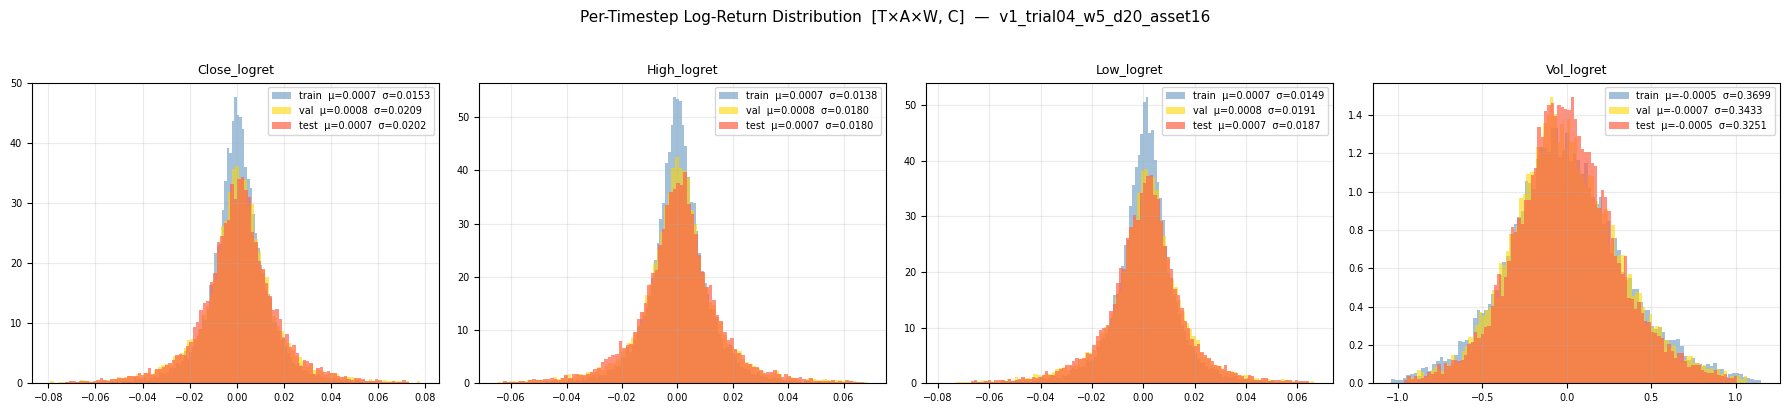

✓ v1_trial04_w5_d20_asset16_4b.1_timestep_dist.png
✓ v1_trial04_w5_d20_asset16_4b.1_timestep_dist_stats.csv
split      channel      mean      std      skew      kurt       p01      p99
train Close_logret  0.000740 0.015295  0.923321 21.735224 -0.041723 0.042702
train  High_logret  0.000738 0.013772  1.773302 33.262700 -0.035288 0.039529
train   Low_logret  0.000747 0.014855 -0.162208 22.938924 -0.041178 0.039919
train   Vol_logret -0.000458 0.369898  0.246838  1.343305 -0.881441 0.995003
  val Close_logret  0.000816 0.020928 -0.407287 12.869421 -0.060397 0.062754
  val  High_logret  0.000809 0.018025  0.142831 13.818771 -0.051469 0.056442
  val   Low_logret  0.000818 0.019113 -0.539291 11.948886 -0.058280 0.054149
  val   Vol_logret -0.000670 0.343312  0.305367  1.243720 -0.823128 0.920660
 test Close_logret  0.000691 0.020200  0.075910 12.518663 -0.058086 0.057747
 test  High_logret  0.000677 0.018005  0.422166 16.308086 -0.050285 0.053992
 test   Low_logret  0.000691 0.018719 -0.4044

In [37]:
fig, axes = plt.subplots(1, len(CH_NAMES), figsize=(len(CH_NAMES) * 4.5, 4))

for c, ch in enumerate(CH_NAMES):
    ax = axes[c]
    for split in ["train", "val", "test"]:
        x = data[split]["x"]                  # [T, A, W, D, C]
        # D=0 → most recent sequence, flatten T*A*W
        if x.ndim == 5:
            vals = x[:, :, :, 0, c].flatten()  # [T*A*W]
        else:
            vals = x[:, :, :, c].flatten()      # [T, A, W, C] no-seq case

        # clip extreme outliers for display only
        lo, hi = np.percentile(vals, 0.5), np.percentile(vals, 99.5)
        vals_clipped = vals[(vals >= lo) & (vals <= hi)]

        ax.hist(vals_clipped, bins=100, density=True,
                color=SPLIT_COLORS[split], alpha=SPLIT_ALPHA[split],
                label=f"{split}  μ={vals.mean():.4f}  σ={vals.std():.4f}",
                edgecolor="none")

    ax.set_title(ch, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=7)

fig.suptitle(f"Per-Timestep Log-Return Distribution  [T×A×W, C]  —  {cfg.name}", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(aplot("4b.1_timestep_dist.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4b.1_timestep_dist.png').name}")

# stats table
rows = []
for split in ["train", "val", "test"]:
    x = data[split]["x"]
    for c, ch in enumerate(CH_NAMES):
        vals = (x[:, :, :, 0, c] if x.ndim == 5 else x[:, :, :, c]).flatten()
        rows.append({
            "split": split, "channel": ch,
            "mean": vals.mean(), "std": vals.std(),
            "skew": float(pd.Series(vals).skew()),
            "kurt": float(pd.Series(vals).kurt()),
            "p01": np.percentile(vals, 1), "p99": np.percentile(vals, 99),
        })
timestep_stats = pd.DataFrame(rows).round(6)
timestep_stats.to_csv(atable("4b.1_timestep_dist_stats.csv"), index=False)
print(f"✓ {atable('4b.1_timestep_dist_stats.csv').name}")
print(timestep_stats.to_string(index=False))

## 4b.2  Per-Window Distribution  [T*A, W*C]

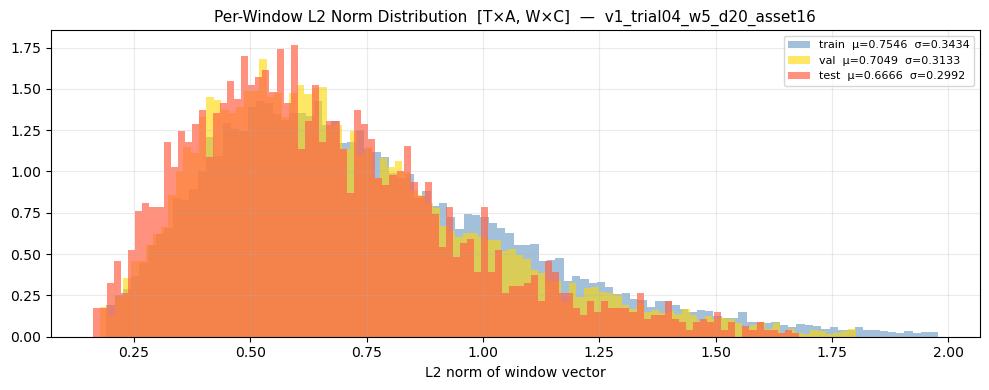

✓ v1_trial04_w5_d20_asset16_4b.2_window_norm_dist.png


In [38]:
# flatten: [T, A, W, C] → [T*A, W*C]
def flatten_windows(x_arr):
    """x_arr: [T, A, W, D, C] or [T, A, W, C] → [T*A, W*C]"""
    if x_arr.ndim == 5:
        x_arr = x_arr[:, :, :, 0, :]   # take D=0 → [T, A, W, C]
    T, A, W, C = x_arr.shape
    return x_arr.transpose(0, 1, 2, 3).reshape(T * A, W * C)

X_flat = {s: flatten_windows(data[s]["x"]) for s in ["train", "val", "test"]}
# shape each: [T*A, W*C]

# per-window L2 norm distribution (สรุป "ขนาด" ของ window)
fig, ax = plt.subplots(figsize=(10, 4))
for split in ["train", "val", "test"]:
    norms = np.linalg.norm(X_flat[split], axis=1)
    lo, hi = np.percentile(norms, 0.5), np.percentile(norms, 99.5)
    norms_c = norms[(norms >= lo) & (norms <= hi)]
    ax.hist(norms_c, bins=100, density=True,
            color=SPLIT_COLORS[split], alpha=SPLIT_ALPHA[split],
            label=f"{split}  μ={norms.mean():.4f}  σ={norms.std():.4f}",
            edgecolor="none")

ax.set_title(f"Per-Window L2 Norm Distribution  [T×A, W×C]  —  {cfg.name}", fontsize=11)
ax.set_xlabel("L2 norm of window vector")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(aplot("4b.2_window_norm_dist.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4b.2_window_norm_dist.png').name}")

## 4b.3  PCA on x_base — coloured by split

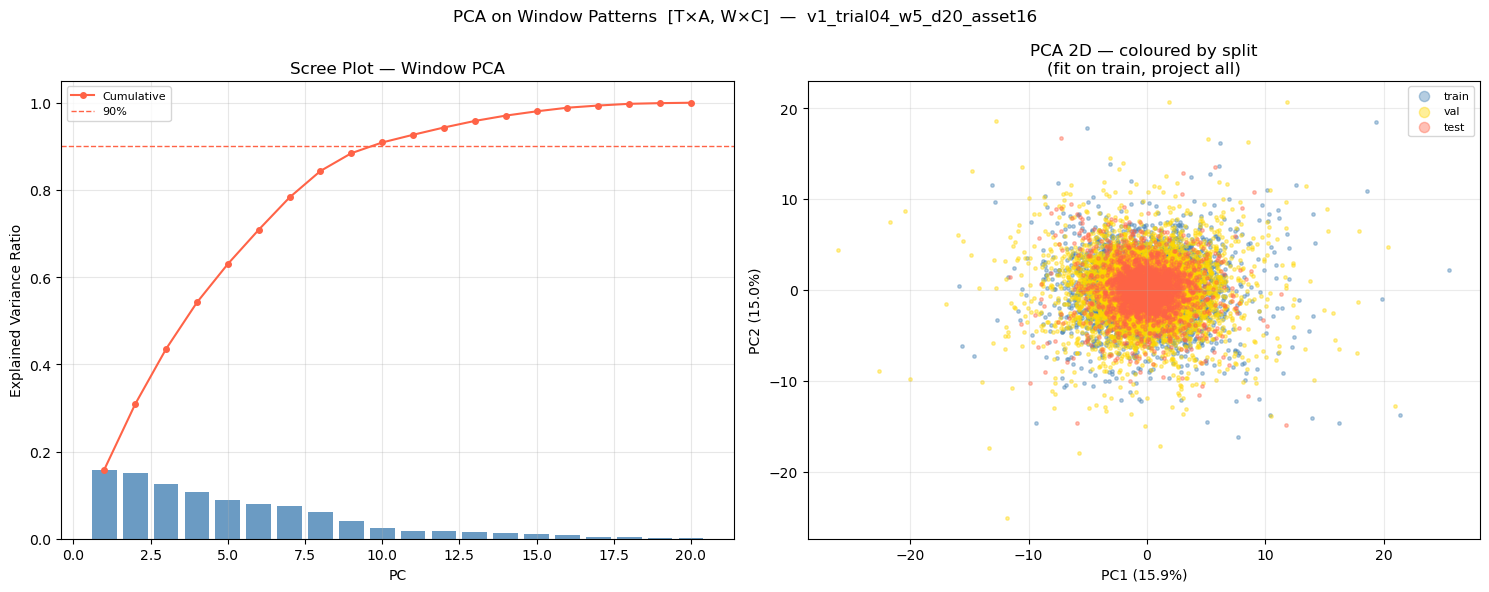

✓ v1_trial04_w5_d20_asset16_4b.3_window_pca.png
  Components@90%: 10  (out of 20)


In [39]:
X_train_flat = X_flat["train"]
X_val_flat   = X_flat["val"]
X_test_flat  = X_flat["test"]

sk_scaler_w = SKStandardScaler().fit(X_train_flat)
X_tr_sc = sk_scaler_w.transform(X_train_flat)
X_va_sc = sk_scaler_w.transform(X_val_flat)
X_te_sc = sk_scaler_w.transform(X_test_flat)

pca_w = PCA(n_components=min(20, X_tr_sc.shape[1])).fit(X_tr_sc)
cum_var_w = np.cumsum(pca_w.explained_variance_ratio_)

# project all splits onto train PCA
P_tr = pca_w.transform(X_tr_sc)[:, :2]
P_va = pca_w.transform(X_va_sc)[:, :2]
P_te = pca_w.transform(X_te_sc)[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: scree
axes[0].bar(range(1, len(cum_var_w)+1), pca_w.explained_variance_ratio_,
            color="steelblue", alpha=0.8)
axes[0].plot(range(1, len(cum_var_w)+1), cum_var_w,
             color="tomato", marker="o", ms=4, label="Cumulative")
axes[0].axhline(0.90, color="tomato", ls="--", lw=1, label="90%")
axes[0].set_title("Scree Plot — Window PCA")
axes[0].set_xlabel("PC")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# right: 2D scatter coloured by split
for P, split in [(P_tr, "train"), (P_va, "val"), (P_te, "test")]:
    axes[1].scatter(P[:, 0], P[:, 1],
                    color=SPLIT_COLORS[split], alpha=0.4, s=6, label=split)

axes[1].set_title(f"PCA 2D — coloured by split\n(fit on train, project all)")
axes[1].set_xlabel(f"PC1 ({pca_w.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_w.explained_variance_ratio_[1]:.1%})")
axes[1].legend(fontsize=8, markerscale=3)
axes[1].grid(alpha=0.25)

fig.suptitle(f"PCA on Window Patterns  [T×A, W×C]  —  {cfg.name}", fontsize=12)
plt.tight_layout()
plt.savefig(aplot("4b.3_window_pca.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4b.3_window_pca.png').name}")

# save PCA summary
n90_w = int(np.argmax(cum_var_w >= 0.90)) + 1
pd.DataFrame([{
    "n_components_90pct": n90_w,
    "total_dims"        : X_tr_sc.shape[1],
    "pc1_var"           : pca_w.explained_variance_ratio_[0],
    "pc2_var"           : pca_w.explained_variance_ratio_[1],
}]).to_csv(atable("4b.3_window_pca_summary.csv"), index=False)
print(f"  Components@90%: {n90_w}  (out of {X_tr_sc.shape[1]})")

## 4b.4  t-SNE on x_base — coloured by split + vol regime

Running t-SNE on 3000 samples...
t-SNE done.


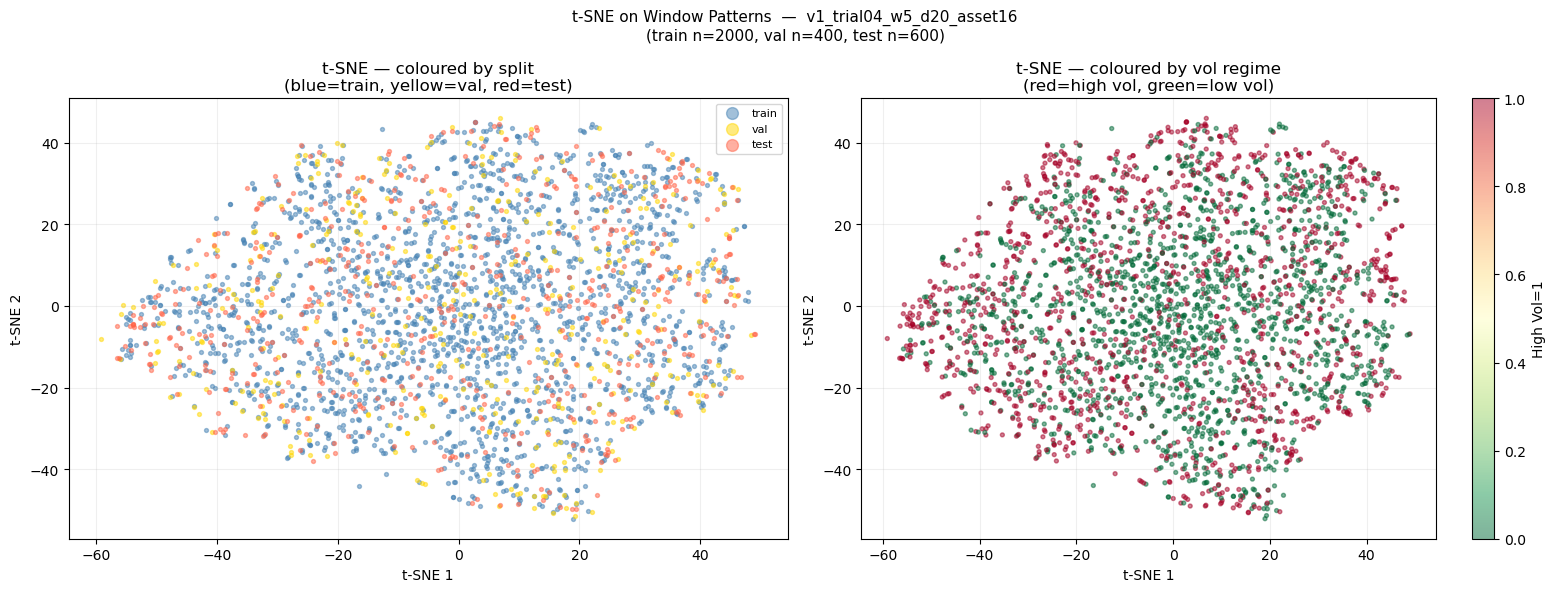

✓ v1_trial04_w5_d20_asset16_4b.4_window_tsne.png


In [40]:
N_SAMPLE = 2000
rng = np.random.default_rng(cfg.random_seed)

n_tr = len(X_tr_sc)
n_va = len(X_va_sc)
n_te = len(X_te_sc)

idx_tr = rng.choice(n_tr, min(N_SAMPLE, n_tr), replace=False)
idx_va = rng.choice(n_va, min(int(N_SAMPLE * 0.2), n_va), replace=False)
idx_te = rng.choice(n_te, min(int(N_SAMPLE * 0.3), n_te), replace=False)

# PCA pre-reduce ก่อน t-SNE
n_pca_for_tsne = max(2, min(n90_w, 50))
X_pca50 = PCA(n_components=n_pca_for_tsne).fit(X_tr_sc)

X_tsne_input = np.concatenate([
    X_pca50.transform(X_tr_sc[idx_tr]),
    X_pca50.transform(X_va_sc[idx_va]),
    X_pca50.transform(X_te_sc[idx_te]),
], axis=0)

split_labels = (
    ["train"] * len(idx_tr) +
    ["val"]   * len(idx_va) +
    ["test"]  * len(idx_te)
)

# rolling vol regime label (ใช้จาก Section 4 ถ้ามี, ไม่งั้น recompute)
close_train = splits["train"].xs("Close", axis=1, level=0)
log_ret_all = pd.concat([
    np.log(splits[s].xs("Close", axis=1, level=0) /
           splits[s].xs("Close", axis=1, level=0).shift(1)).dropna()
    for s in ["train", "val", "test"]
])
roll_vol_all = log_ret_all.rolling(cfg.window_size).std().mean(axis=1) * np.sqrt(252)
vol_med = roll_vol_all.quantile(0.5)

# map window end-date → vol regime
# data[split]["dates"] shape [T, W] → last date of each window = dates[:, -1]
def get_vol_regime(split, idx_sel):
    A = len(assets)
    t_idx     = idx_sel // A                              # [T*A, W*C] → กลับเป็น T index
    end_dates = pd.to_datetime(data[split]["dates"][t_idx, -1])
    regimes   = []
    for d in end_dates:
        closest = roll_vol_all.index.get_indexer([d], method="nearest")[0]
        v = roll_vol_all.iloc[closest]
        regimes.append(1 if v > vol_med else 0)
    return regimes

vol_regimes = (
    get_vol_regime("train", idx_tr) +
    get_vol_regime("val",   idx_va) +
    get_vol_regime("test",  idx_te)
)

print(f"Running t-SNE on {len(X_tsne_input)} samples...")
tsne_w = TSNE(n_components=2, perplexity=30, max_iter=1000,
              random_state=cfg.random_seed)
X_tsne_w = tsne_w.fit_transform(X_tsne_input)
print("t-SNE done.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left: coloured by split
for split in ["train", "val", "test"]:
    mask = [l == split for l in split_labels]
    axes[0].scatter(X_tsne_w[mask, 0], X_tsne_w[mask, 1],
                    color=SPLIT_COLORS[split], alpha=0.5, s=8, label=split)
axes[0].set_title("t-SNE — coloured by split\n(blue=train, yellow=val, red=test)")
axes[0].legend(fontsize=8, markerscale=3)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].grid(alpha=0.2)

# right: coloured by vol regime
sc2 = axes[1].scatter(X_tsne_w[:, 0], X_tsne_w[:, 1],
                       c=vol_regimes, cmap="RdYlGn_r", alpha=0.5, s=8)
axes[1].set_title("t-SNE — coloured by vol regime\n(red=high vol, green=low vol)")
plt.colorbar(sc2, ax=axes[1], label="High Vol=1")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.2)

fig.suptitle(f"t-SNE on Window Patterns  —  {cfg.name}\n"
             f"(train n={len(idx_tr)}, val n={len(idx_va)}, test n={len(idx_te)})",
             fontsize=11)
plt.tight_layout()
plt.savefig(aplot("4b.4_window_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ {aplot('4b.4_window_tsne.png').name}")

## 4b.5  Distribution Shift Summary

In [41]:
def pc_stats(P, name):
    return {
        "split"    : name,
        "n"        : len(P),
        "pc1_mean" : P[:, 0].mean(),
        "pc1_std"  : P[:, 0].std(),
        "pc2_mean" : P[:, 1].mean(),
        "pc2_std"  : P[:, 1].std(),
        "pc1_drift": None,   # fill below
        "pc2_drift": None,
    }

rows_pc = [pc_stats(P_tr, "train"),
           pc_stats(P_va, "val"),
           pc_stats(P_te, "test")]

tr_pc1_mean = rows_pc[0]["pc1_mean"]
tr_pc2_mean = rows_pc[0]["pc2_mean"]
for r in rows_pc:
    r["pc1_drift"] = abs(r["pc1_mean"] - tr_pc1_mean)
    r["pc2_drift"] = abs(r["pc2_mean"] - tr_pc2_mean)

shift_df = pd.DataFrame(rows_pc).round(4)
shift_df.to_csv(atable("4b.5_distribution_shift.csv"), index=False)
print(f"✓ {atable('4b.5_distribution_shift.csv').name}")

print("\n" + "=" * 60)
print(f"  4b SUMMARY — Distribution Shift  [{cfg.name}]")
print("=" * 60)
print(shift_df.to_string(index=False))

print("\n  Interpretation:")
for _, r in shift_df.iterrows():
    if r["split"] == "train":
        continue
    pc1_flag = "⚠️  HIGH" if r["pc1_drift"] > P_tr[:, 0].std() else "✓  OK"
    pc2_flag = "⚠️  HIGH" if r["pc2_drift"] > P_tr[:, 1].std() else "✓  OK"
    print(f"  [{r['split']:5s}]  PC1 drift={r['pc1_drift']:.3f} {pc1_flag}  |  "
          f"PC2 drift={r['pc2_drift']:.3f} {pc2_flag}")

print(f"\n  → ถ้า test PC drift สูง = window patterns ที่ model เห็นตอน test")
print(f"    อยู่นอก distribution ที่ train บน → อธิบาย performance drop ได้")

✓ v1_trial04_w5_d20_asset16_4b.5_distribution_shift.csv

  4b SUMMARY — Distribution Shift  [v1_trial04_w5_d20_asset16]
split     n  pc1_mean  pc1_std  pc2_mean  pc2_std  pc1_drift  pc2_drift
train 21936    0.0000   1.7819   -0.0000   1.7318     0.0000     0.0000
  val 15424    0.0188   2.3137   -0.0037   2.2381     0.0188     0.0037
 test  3056   -0.0158   2.1524    0.0275   2.3097     0.0158     0.0275

  Interpretation:
  [val  ]  PC1 drift=0.019 ✓  OK  |  PC2 drift=0.004 ✓  OK
  [test ]  PC1 drift=0.016 ✓  OK  |  PC2 drift=0.028 ✓  OK

  → ถ้า test PC drift สูง = window patterns ที่ model เห็นตอน test
    อยู่นอก distribution ที่ train บน → อธิบาย performance drop ได้


# 7. Scaler Factory + Fit/Transform/Inverse helpers

In [42]:
def create_scaler(scaler_type: str):
    if scaler_type == "standard":
        return StandardScaler()
    elif scaler_type == "robust":
        return RobustScaler()
    elif scaler_type == "minmax":
        from sklearn.preprocessing import MinMaxScaler
        return MinMaxScaler()
    elif scaler_type is None:
        return None

    raise ValueError(f"Unknown scaler type: {scaler_type}")

def fit_scaler_x(x_train: np.ndarray, scaler_type: str):
    """
    Fit scaler on x_train per-channel, global across T, A, W, D.

    x_train : [T, A, W, D, C]
    returns  : fitted scaler (or None)
    """
    if scaler_type == "none":
        return None
    scaler = create_scaler(scaler_type)
    T, A, W, D, C = x_train.shape
    flat = x_train.reshape(-1, C)      # [T*A*W*D, C]
    scaler.fit(flat)
    return scaler

def transform_x(x: np.ndarray, scaler) -> np.ndarray:
    """Apply fitted x scaler. x: [T, A, W, D, C]"""
    if scaler is None:
        return x
    shape = x.shape
    return scaler.transform(x.reshape(-1, shape[-1])).reshape(shape)

def inverse_transform_x(x_scaled: np.ndarray, scaler) -> np.ndarray:
    """Inverse transform x back to original scale. x_scaled: [T, A, W, D, C]"""
    if scaler is None:
        return x_scaled
    shape = x_scaled.shape
    return scaler.inverse_transform(x_scaled.reshape(-1, shape[-1])).reshape(shape)


# cond helpers
# ──────────────────────────────────────────────────────────────

def _get_feat_idx(feat_names: list, names: list) -> list:
    """Return indices of `names` inside `feat_names`."""
    return [feat_names.index(n) for n in names if n in feat_names]

def _clip_cond(cond: np.ndarray, feat_names: list,
               clip_ranges: dict) -> np.ndarray:
    """Clip outlier features before fitting/transforming."""
    cond = cond.copy()
    for fname, (lo, hi) in clip_ranges.items():
        if fname in feat_names:
            idx = feat_names.index(fname)
            cond[..., idx] = np.clip(cond[..., idx], lo, hi)
    return cond

def fit_scaler_cond(cond_train: np.ndarray, feat_names: list,
                    scaler_type: str,
                    no_scale: list = cfg.scaler_exclude_features,
                    clip_ranges: dict = cfg.scaler_clip_ranges):
    """
    Fit scaler on cond_train per-feature global, with:
      - weekday_sin/cos excluded (passthrough)
      - BBANDS clipped before fit

    cond_train : [T, A, W, F]
    returns    : (scaler, scale_idx, noscale_idx)
      scale_idx   — feature indices that ARE scaled
      noscale_idx — feature indices that are NOT scaled (weekday)
    """
    no_scale_idx = _get_feat_idx(feat_names, no_scale)
    scale_idx    = [i for i in range(len(feat_names)) if i not in no_scale_idx]

    if scaler_type == "none":
        return None, scale_idx, no_scale_idx

    scaler = create_scaler(scaler_type)

    # clip outliers before fit
    cond_clipped = _clip_cond(cond_train, feat_names, clip_ranges)

    T, A, W, F = cond_clipped.shape
    flat = cond_clipped.reshape(-1, F)          # [T*A*W, F]
    scaler.fit(flat[:, scale_idx])              # fit on scalable features only
    return scaler, scale_idx, no_scale_idx

def transform_cond(cond: np.ndarray, scaler,
                   scale_idx: list, feat_names: list,
                   clip_ranges: dict) -> np.ndarray:
    """
    Transform cond:
      1. clip BBANDS outliers
      2. scale scalable features
      3. leave weekday as-is
    """
    cond_out = _clip_cond(cond, feat_names, clip_ranges).copy()

    if scaler is None:
        return cond_out

    shape = cond_out.shape
    flat  = cond_out.reshape(-1, shape[-1])
    flat[:, scale_idx] = scaler.transform(flat[:, scale_idx])
    return flat.reshape(shape)

def inverse_transform_cond(cond_scaled: np.ndarray, scaler,
                           scale_idx: list) -> np.ndarray:
    """
    Inverse transform — only scalable features.
    weekday_sin/cos passthrough (ไม่ถูก scale ตั้งแต่แรก)
    NOTE: BBANDS ที่ถูก clip ไปแล้ว จะ inverse กลับมาเป็น clipped value
          ไม่ใช่ค่า original ที่เกิน clip range
    """
    cond_out = cond_scaled.copy()

    if scaler is None:
        return cond_out

    shape = cond_out.shape
    flat  = cond_out.reshape(-1, shape[-1])
    flat[:, scale_idx] = scaler.inverse_transform(flat[:, scale_idx])
    return flat.reshape(shape)

## 7.1 Pre-scale Check Distribution (Before scaled)

In [43]:
def check_distribution(x: np.ndarray, cond: np.ndarray,
                        x_label: str = "x (raw)",
                        cond_label: str = "cond (raw)"):
    """
    Quick stats check per-channel for x and per-feature for cond.
    ดูก่อนว่า distribution เป็นยังไง ก่อน scale
    """
    channel_names = ["Close_logret", "High_logret", "Low_logret", "Vol_logret"]
    C = x.shape[-1]

    print(f"{'─'*60}")
    print(f"  {x_label}  shape={x.shape}")
    print(f"{'─'*60}")
    flat_x = x.reshape(-1, C)
    for c, name in enumerate(channel_names[:C]):
        col = flat_x[:, c]
        print(f"  [{c}] {name:<20}  "
              f"mean={col.mean():+.4f}  std={col.std():.4f}  "
              f"min={col.min():+.4f}  max={col.max():+.4f}")

    print(f"\n{'─'*60}")
    print(f"  {cond_label}  shape={cond.shape}")
    print(f"{'─'*60}")
    F = cond.shape[-1]
    flat_c = cond.reshape(-1, F)
    feat_names = [col for col in df_feat_train.xs("AAPL", axis=1, level=1).columns]
    for f in range(F):
        col = flat_c[:, f]
        fname = feat_names[f] if f < len(feat_names) else f"feat_{f}"
        print(f"  [{f}] {fname:<35}  "
              f"mean={col.mean():+.6f}  std={col.std():.6f}  "
              f"min={col.min():+.6f}  max={col.max():+.6f}")


# Run pre-scale check
x_train_raw   = data["train"]["x"]      # [T, A, W, D, C]
cond_train_raw = data["train"]["cond"]  # [T, A, W, F]

print("=" * 60)
print("  PRE-SCALE DISTRIBUTION CHECK")
print("=" * 60)
check_distribution(x_train_raw, cond_train_raw)


  PRE-SCALE DISTRIBUTION CHECK
────────────────────────────────────────────────────────────
  x (raw)  shape=(1371, 16, 5, 20, 4)
────────────────────────────────────────────────────────────
  [0] Close_logret          mean=+0.0001  std=0.0059  min=-0.1567  max=+0.2609
  [1] High_logret           mean=+0.0001  std=0.0053  min=-0.1401  max=+0.2736
  [2] Low_logret            mean=+0.0001  std=0.0058  min=-0.2387  max=+0.2289
  [3] Vol_logret            mean=-0.0001  std=0.1433  min=-1.7508  max=+2.4988

────────────────────────────────────────────────────────────
  cond (raw)  shape=(1371, 16, 5, 11)
────────────────────────────────────────────────────────────
  [0] ATR_14_minmax                        mean=+0.452067  std=0.383880  min=+0.000000  max=+1.000000
  [1] BBANDS_lowerband_distance_close      mean=+0.049752  std=0.050729  min=-0.082651  max=+0.636502
  [2] BBANDS_middleband_distance_close     mean=+0.005867  std=0.036614  min=-0.382136  max=+0.364294
  [3] BBANDS_upperband_dis

## 7.2 Fit Scalers on Train Only

In [44]:
x_train_raw    = data["train"]["x"]       # [T, A, W, D, C]
cond_train_raw = data["train"]["cond"]    # [T, A, W, F]

x_scaler_type    = cfg.x_scaler      # "standard"
cond_scaler_type = cfg.cond_scaler   # "robust"

print(f"Fitting x_scaler    : {x_scaler_type}  (per-channel global)")
print(f"Fitting cond_scaler : {cond_scaler_type}  (per-feature global)")
print(f"  no_scale features : {cfg.scaler_exclude_features}")
print(f"  clip features     : {list(cfg.scaler_clip_ranges.keys())}")

x_scaler = fit_scaler_x(x_train_raw, x_scaler_type)

cond_scaler, scale_idx, noscale_idx = fit_scaler_cond(
    cond_train_raw, feat_cols, cond_scaler_type
)

print(f"\n  cond scale_idx    : {scale_idx}  → {[feat_cols[i] for i in scale_idx]}")
print(f"  cond noscale_idx  : {noscale_idx}  → {[feat_cols[i] for i in noscale_idx]}")

# ── Scale all splits using train scaler only ──────────────────
data_scaled = {}
for split_name, d in data.items():
    data_scaled[split_name] = {
        **d,
        "x"   : transform_x(d["x"], x_scaler),
        "cond": transform_cond(d["cond"], cond_scaler, scale_idx, feat_cols, cfg.scaler_clip_ranges),
    }

print("\nDone. Scaled splits:")
for name, d in data_scaled.items():
    print(f"  {name:<6}  x={d['x'].shape}  cond={d['cond'].shape}")


Fitting x_scaler    : robust  (per-channel global)
Fitting cond_scaler : standard  (per-feature global)
  no_scale features : ['weekday_sin', 'weekday_cos']
  clip features     : ['BBANDS_lowerband_distance_close', 'BBANDS_middleband_distance_close', 'BBANDS_upperband_distance_close']

  cond scale_idx    : [0]  → ['log_return']
  cond noscale_idx  : []  → []

Done. Scaled splits:
  train   x=(1371, 16, 5, 20, 4)  cond=(1371, 16, 5, 11)
  val     x=(964, 16, 5, 20, 4)  cond=(964, 16, 5, 11)
  test    x=(191, 16, 5, 20, 4)  cond=(191, 16, 5, 11)


## 7.3 Post-scale Check distribution (After scaled)

In [45]:
print("=" * 60)
print("  POST-SCALE DISTRIBUTION CHECK")
print("=" * 60)
check_distribution(
    data_scaled["train"]["x"],
    data_scaled["train"]["cond"],
    x_label="x (scaled)",
    cond_label="cond (scaled)",
)


  POST-SCALE DISTRIBUTION CHECK
────────────────────────────────────────────────────────────
  x (scaled)  shape=(1371, 16, 5, 20, 4)
────────────────────────────────────────────────────────────
  [0] Close_logret          mean=+0.0001  std=0.0059  min=-0.1567  max=+0.2609
  [1] High_logret           mean=+0.0001  std=0.0053  min=-0.1401  max=+0.2736
  [2] Low_logret            mean=+0.0001  std=0.0058  min=-0.2387  max=+0.2289
  [3] Vol_logret            mean=-0.0001  std=0.1433  min=-1.7508  max=+2.4988

────────────────────────────────────────────────────────────
  cond (scaled)  shape=(1371, 16, 5, 11)
────────────────────────────────────────────────────────────
  [0] ATR_14_minmax                        mean=-0.000000  std=1.000000  min=-1.177623  max=+1.427354
  [1] BBANDS_lowerband_distance_close      mean=+0.049752  std=0.050729  min=-0.082651  max=+0.636502
  [2] BBANDS_middleband_distance_close     mean=+0.005867  std=0.036614  min=-0.382136  max=+0.364294
  [3] BBANDS_upperb

## 7.4 Inverse Transform Sanity Check

In [46]:
print("=" * 60)
print("  INVERSE TRANSFORM SANITY CHECK")
print("=" * 60)

def check_inverse(original, scaled, inv_fn, label, tol=1e-5, **inv_kwargs):
    reconstructed = inv_fn(scaled, **inv_kwargs)
    max_err  = np.abs(reconstructed - original).max()
    mean_err = np.abs(reconstructed - original).mean()
    match    = max_err < tol

    print(f"\n  [{label}]")
    print(f"    max  abs error : {max_err:.2e}   {'✓ OK' if match else '✗ FAIL'}")
    print(f"    mean abs error : {mean_err:.2e}")

    t, a = 10, 0
    orig_s  = original[t, a].flatten()[:5]
    recon_s = reconstructed[t, a].flatten()[:5]
    print(f"    spot check [t={t}, a={a}] first 5:")
    print(f"      original : {np.array2string(orig_s, precision=6)}")
    print(f"      recon    : {np.array2string(recon_s, precision=6)}")
    return match

ok_x = check_inverse(
    data["train"]["x"],
    data_scaled["train"]["x"],
    lambda s, scaler: inverse_transform_x(s, scaler),
    label="x  (log returns)",
    scaler=x_scaler,
)

cond_clipped = _clip_cond(data["train"]["cond"], feat_cols, cfg.scaler_clip_ranges)
cond_scaled  = data_scaled["train"]["cond"]
cond_inv     = inverse_transform_cond(cond_scaled, cond_scaler, scale_idx)

# NOTE: cond inverse จะ match เฉพาะ features ที่ไม่ถูก clip
# weekday → exact match, BBANDS ที่เกิน clip range → จะไม่ match กับ original
ok_cond = check_inverse(
    cond_clipped,   # ← ground truth คือ clipped (ไม่ใช่ raw original)
    cond_scaled,
    lambda s, scaler, sidx: inverse_transform_cond(s, scaler, sidx),
    label="cond (clipped → scaled → inverse)",
    tol=1e-10,
    scaler=cond_scaler,
    sidx=scale_idx,
)

print(f"\n{'─'*60}")
print(f"  x    inverse check : {'PASS ✓' if ok_x    else 'FAIL ✗'}")
print(f"  cond inverse check : {'PASS ✓' if ok_cond else 'FAIL ✗'}")
print(f"\n  ⚠️  cond original vs inverse จะไม่ exact match สำหรับ BBANDS")
print(f"      เพราะ clip ทิ้ง extreme values ตั้งแต่ก่อน scale (by design)")


  INVERSE TRANSFORM SANITY CHECK

  [x  (log returns)]
    max  abs error : 0.00e+00   ✓ OK
    mean abs error : 0.00e+00
    spot check [t=10, a=0] first 5:
      original : [ 0.016726  0.022966  0.027998 -0.063346  0.      ]
      recon    : [ 0.016726  0.022966  0.027998 -0.063346  0.      ]

  [cond (clipped → scaled → inverse)]
    max  abs error : 1.11e-16   ✓ OK
    mean abs error : 1.28e-18
    spot check [t=10, a=0] first 5:
      original : [ 0.045006  0.062196  0.012963 -0.03627   0.276709]
      recon    : [ 0.045006  0.062196  0.012963 -0.03627   0.276709]

────────────────────────────────────────────────────────────
  x    inverse check : PASS ✓
  cond inverse check : PASS ✓

  ⚠️  cond original vs inverse จะไม่ exact match สำหรับ BBANDS
      เพราะ clip ทิ้ง extreme values ตั้งแต่ก่อน scale (by design)


## 7.5 Diff Check between (Before Scaled, and After Scaled Inverse Transformed)

In [47]:
x_inv    = inverse_transform_x(data_scaled["train"]["x"], x_scaler)
cond_inv = inverse_transform_cond(data_scaled["train"]["cond"], cond_scaler, scale_idx)

print("=" * 60)
print("  INVERSE DISTRIBUTION CHECK  (should match PRE-SCALE)")
print("=" * 60)
check_distribution(x_inv, cond_inv,
                   x_label="x (inverse)",
                   cond_label="cond (inverse)")

  INVERSE DISTRIBUTION CHECK  (should match PRE-SCALE)
────────────────────────────────────────────────────────────
  x (inverse)  shape=(1371, 16, 5, 20, 4)
────────────────────────────────────────────────────────────
  [0] Close_logret          mean=+0.0001  std=0.0059  min=-0.1567  max=+0.2609
  [1] High_logret           mean=+0.0001  std=0.0053  min=-0.1401  max=+0.2736
  [2] Low_logret            mean=+0.0001  std=0.0058  min=-0.2387  max=+0.2289
  [3] Vol_logret            mean=-0.0001  std=0.1433  min=-1.7508  max=+2.4988

────────────────────────────────────────────────────────────
  cond (inverse)  shape=(1371, 16, 5, 11)
────────────────────────────────────────────────────────────
  [0] ATR_14_minmax                        mean=+0.452067  std=0.383880  min=+0.000000  max=+1.000000
  [1] BBANDS_lowerband_distance_close      mean=+0.049752  std=0.050729  min=-0.082651  max=+0.636502
  [2] BBANDS_middleband_distance_close     mean=+0.005867  std=0.036614  min=-0.382136  max=+0.3

In [48]:
def diff_check(original, reconstructed, feat_names, label):
    C = original.shape[-1]
    flat_orig  = original.reshape(-1, C)
    flat_recon = reconstructed.reshape(-1, C)

    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")
    print(f"  {'feature':<35}  {'orig_mean':>10}  {'recon_mean':>10}  {'max_diff':>12}  match")
    print(f"  {'─'*35}  {'─'*10}  {'─'*10}  {'─'*12}  ─────")

    all_match = True
    for c in range(C):
        orig_col  = flat_orig[:, c]
        recon_col = flat_recon[:, c]
        max_diff  = np.abs(orig_col - recon_col).max()
        match     = max_diff < 1e-10
        all_match = all_match and match
        name      = feat_names[c] if c < len(feat_names) else f"feat_{c}"
        flag      = "✓" if match else f"✗ {max_diff:.2e}"
        print(f"  {name:<35}  {orig_col.mean():>+10.6f}  {recon_col.mean():>+10.6f}  {max_diff:>12.2e}  {flag}")

    print(f"\n  → {'ALL MATCH ✓' if all_match else 'MISMATCH FOUND ✗'}")
    return all_match


x_inv    = inverse_transform_x(data_scaled["train"]["x"], x_scaler)
cond_inv = inverse_transform_cond(data_scaled["train"]["cond"], cond_scaler, scale_idx)

ch_names   = ["Close_logret", "High_logret", "Low_logret", "Vol_logret"]
feat_names = df_feat_train.xs("AAPL", axis=1, level=1).columns.tolist()

diff_check(data["train"]["x"],    x_inv,    ch_names,   "x    : original vs inverse")
diff_check(data["train"]["cond"], cond_inv, feat_names, "cond : original vs inverse")


──────────────────────────────────────────────────────────────────────
  x    : original vs inverse
──────────────────────────────────────────────────────────────────────
  feature                               orig_mean  recon_mean      max_diff  match
  ───────────────────────────────────  ──────────  ──────────  ────────────  ─────
  Close_logret                          +0.000111   +0.000111      0.00e+00  ✓
  High_logret                           +0.000111   +0.000111      0.00e+00  ✓
  Low_logret                            +0.000112   +0.000112      0.00e+00  ✓
  Vol_logret                            -0.000067   -0.000067      0.00e+00  ✓

  → ALL MATCH ✓

──────────────────────────────────────────────────────────────────────
  cond : original vs inverse
──────────────────────────────────────────────────────────────────────
  feature                               orig_mean  recon_mean      max_diff  match
  ───────────────────────────────────  ──────────  ──────────  ───────────

np.True_

In [49]:
# ============================================================
# CELL — Inverse Log Return → Price
# ============================================================

def inverse_log_return_to_price(x_scaled: np.ndarray,
                                 init_price: np.ndarray,
                                 x_scaler) -> np.ndarray:
    """
    x_scaled   : [T, A, W, D, C]  — scaled log returns
    init_price : [T, A]            — price ก่อน window (Close)
    x_scaler   : fitted StandardScaler

    returns    : price_recon [T, A, W, C]  — reconstructed price
                 (collapse D dimension โดยใช้ D=0 ซึ่งคือ sequence ล่าสุด)
    """
    # 1. inverse scaler → log returns
    x_lr = inverse_transform_x(x_scaled, x_scaler)   # [T, A, W, D, C]

    # 2. เอา D=0 (most recent sequence) — shape [T, A, W, C]
    x_lr = x_lr[:, :, :, 0, :]

    # 3. cumsum along W axis → cumulative log return
    x_cum = np.cumsum(x_lr, axis=2)                   # [T, A, W, C]

    # 4. init_price [T, A] → [T, A, 1, 1] เพื่อ broadcast
    init = init_price[:, :, None, None]               # [T, A, 1, 1]

    # 5. exp(cumsum) * init_price → reconstructed price
    price_recon = init * np.exp(x_cum)                # [T, A, W, C]

    return price_recon


# ── Sanity Check ──────────────────────────────────────────────
print("=" * 60)
print("  INVERSE LOG RETURN → PRICE CHECK")
print("=" * 60)

price_recon = inverse_log_return_to_price(
    data_scaled["train"]["x"],
    data["train"]["init_price"],
    x_scaler,
)
# [T, A, W, C]

ohlcv_raw   = data["train"]["ohlcv_raw"]   # [T, A, W, 4]  raw price จริง
ch_names    = ["Close", "High", "Low", "Volume"]

print(f"\n  price_recon : {price_recon.shape}")
print(f"  ohlcv_raw   : {ohlcv_raw.shape}")

# ── per-channel max error ──────────────────────────────────────
print(f"\n  {'channel':<10}  {'max_abs_err':>12}  {'mean_abs_err':>13}  match")
print(f"  {'─'*10}  {'─'*12}  {'─'*13}  ─────")

for c, ch in enumerate(ch_names):
    if ch == "Volume":
        # Volume log return → volume จริง ≠ OHLC เพราะ scale ต่างกันมาก
        # skip หรือ check แยก
        print(f"  {ch:<10}  {'(skip — diff unit)':>27}")
        continue
    err     = np.abs(price_recon[..., c] - ohlcv_raw[..., c])
    max_err  = err.max()
    mean_err = err.mean()
    match    = max_err < 1e-4
    print(f"  {ch:<10}  {max_err:>12.6f}  {mean_err:>13.8f}  {'✓' if match else '✗'}")

# ── Spot check — AAPL window@100 ──────────────────────────────
t, a = 100, 0
print(f"\n  Spot check — {assets[a]}  window@{t}  (Close only)")
print(f"  {'step':<6}  {'actual':>10}  {'recon':>10}  {'diff':>10}")
print(f"  {'─'*6}  {'─'*10}  {'─'*10}  {'─'*10}")

for w in range(min(5, price_recon.shape[2])):
    actual = ohlcv_raw[t, a, w, 0]
    recon  = price_recon[t, a, w, 0]
    print(f"  {w:<6}  {actual:>10.4f}  {recon:>10.4f}  {abs(actual-recon):>10.6f}")

  INVERSE LOG RETURN → PRICE CHECK

  price_recon : (1371, 16, 5, 4)
  ohlcv_raw   : (1371, 16, 5, 4)

  channel      max_abs_err   mean_abs_err  match
  ──────────  ────────────  ─────────────  ─────
  Close          15.343068     0.45336452  ✗
  High           16.802210     0.46206856  ✗
  Low            17.397469     0.45152456  ✗
  Volume               (skip — diff unit)

  Spot check — AAPL  window@100  (Close only)
  step        actual       recon        diff
  ──────  ──────────  ──────────  ──────────
  0          16.1048     15.8561    0.248685
  1          16.0012     15.7542    0.247085
  2          16.3507     16.0982    0.252481
  3          16.2785     16.0271    0.251366
  4          15.9973     15.7503    0.247024


# 8. Save Feature Store

In [50]:
print("── Saving variants ───────────────────────────────────────────────────────")
# variant = f"{cfg.x_scaler}_{cfg.cond_scaler}"   # e.g. "standard_robust"

print(f"── Saving variant: {variant} ────────────────────────────────────────────")
save_variant(data_scaled, x_scaler, cond_scaler, cfg, variant)
print("\n✓ Done")

── Saving variants ───────────────────────────────────────────────────────
── Saving variant: robust_standard ────────────────────────────────────────────


  saved train  → /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/train.npz
  saved val    → /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/val.npz
  saved test   → /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/test.npz
  saved scalers  → /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/scalers.pkl
  saved meta     → /home/narodom.y@FUSION.LAB/research/01_processed/v1_trial04_w5_d20_asset16_robust_standard/meta.json

✓ Done


# 9. Download Feature Store

In [51]:
data, scalers = load_variant(cfg.save_dir, cfg.name, variant)
loaders = make_all_dataloaders(cfg.save_dir, cfg.name, variant, cfg.batch_sizes)